# 03 — Preprocesado (implementacion)

> Este notebook IMPLEMENTA lo decidido en `02_diseno_preprocesado.ipynb` y congelado en `data/benchmark_spec.yaml` (ADR-002). No se toman decisiones de diseno aqui: si aparece una, vuelve a 02 / a una nueva ADR, no se improvisa en este notebook.

Entradas: `00_descarga.ipynb` (166 series), `02_diseno_preprocesado.ipynb` (que features, que transformaciones, que alineacion), `data/benchmark_spec.yaml` (ventanas congeladas: Pista A 1962-01-02->2026-05-29 41 series 18/22 crisis; Pista B 2007-04-11->2026-05-29 106 series 10/22 crisis).

Salida: `data/processed/pista{A,B}_{diaria,mensual}.parquet` + `labels.parquet` + `_meta.json`.

## 0. Setup

Este notebook **implementa** (no rediseña) el plan de preprocesado ya congelado en `02_diseno_preprocesado.ipynb` y en `data/benchmark_spec.yaml`: la tabla `FEAT` (78 tuplas, 77 features + 1 fila `solo-raw`), las reglas de frecuencia (§3), la alineación causal sobre calendario NYSE (§4), el recetario de transformaciones (§5) y la estructura de salida `data/processed/pista{A,B}_{diaria,mensual}.parquet` (§8) son un contrato ya aprobado — aquí solo se ejecuta.

Pipeline completo del proyecto: **00 descarga → 01 EDA → 02 diseño → 03 preprocesado (este notebook) → Fase D (detectores)**.

Esta primera sección deja listo el entorno de trabajo:

- Resolvemos `ROOT` subiendo directorios hasta encontrar `data/catalog.yaml` — el mismo patrón exacto usado en 00/01/02, para que el notebook funcione sin importar desde qué subcarpeta se lance Jupyter.
- Añadimos `ROOT` a `sys.path` e importamos `src.features` como `ft`: ahí viven las primitivas causales ya verificadas en 02 (`causal_zscore`, `log_returns`, `realized_vol`, `drawdown`, `momentum`, `rolling_correlation`) que vamos a reutilizar literalmente, en vez de reescribirlas.
- Cargamos `coverage_report.csv`, el inventario real de qué series están efectivamente descargadas en `data/raw/` (con su `status` OK/CACHE/ERROR y su `fuente`). Es la fuente de verdad de *qué hay en disco*; `catalog.yaml` (metadatos/roles) y `benchmark_spec.yaml` (ventanas, listas de `series_features`, `crisis_windows`) se cargarán más adelante, en la sección donde se usan, siguiendo el mismo patrón de 02 (setup mínimo, carga incremental por sección).

Regla de oro que gobierna todo lo que sigue (repetida de 02 y del `GLOSARIO.md`): **nada de estadísticos de muestra completa** — toda feature usa solo datos `≤ t`.

In [1]:
import sys, warnings
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import yaml

warnings.filterwarnings('ignore')
plt.rcParams.update({'figure.dpi':110,'axes.grid':True,'grid.alpha':.3,'font.size':9,
                     'axes.spines.top':False,'axes.spines.right':False})

ROOT = Path.cwd()
while not (ROOT/'data'/'catalog.yaml').exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

from src import features as ft

print('ROOT:', ROOT)

ROOT: C:\Users\Usuario\Downloads\PRUEBAS_DETECCION_REGIMENES_DE_MERCADO_TFM


In [2]:
cov = pd.read_csv(ROOT/'data'/'raw'/'coverage_report.csv')
cov['inicio_dt'] = pd.to_datetime(cov['inicio']); cov['fin_dt'] = pd.to_datetime(cov['fin'])

print('coverage_report.csv:', cov.shape[0], 'series registradas')
print(cov['status'].value_counts())
cov.head()

coverage_report.csv: 174 series registradas
status
OK       166
ERROR      8
Name: count, dtype: int64


,nombre,fuente,id,pista,rol,status,granularidad,inicio,fin,n_obs,n_cols,error,inicio_dt,fin_dt
0,SP500,yfinance,^GSPC,A,spine,OK,diaria,1927-12-30,2026-07-20,24753,NaN,NaN,1927-12-30,2026-07-20
1,SP500_TR,yfinance,^SP500TR,A,core,OK,diaria,1988-01-04,2026-07-20,9708,NaN,NaN,1988-01-04,2026-07-20
2,SHILLER_SP500_CAPE,github,datasets/s-and-p-500:data/data.csv,A,spine,OK,mensual,1871-01-01,2026-06-01,1866,NaN,NaN,1871-01-01,2026-06-01
3,FF_FACTORS_3_DAILY,academico,F-F_Research_Data_Factors_daily,A,spine,OK,diaria,1926-07-01,2026-05-29,26253,NaN,NaN,1926-07-01,2026-05-29
4,FF_FACTORS_3_MONTHLY,academico,F-F_Research_Data_Factors,A,fallback,OK,mensual,1926-07-01,2026-05-01,1199,NaN,NaN,1926-07-01,2026-05-01


## 1. Resolución de nombres dirigida por catálogo

La sección 6 de `02_diseno_preprocesado.ipynb` dejó anotado un problema concreto: `src/features.py` (heredado de la Capa 1) tiene un `build_features` que indexa el panel crudo con nombres viejos (`SP500`, `TLT`, `IEF`, `HYG`, `GOLD`, `DXY`, `VIX`, `MOVE`, `YIELD_10Y_3M`) hardcodeados en el propio código. Ese builder no sirve para el catálogo v2: si le pasamos el panel crudo actual, revienta con `KeyError` en la primera serie que ya no se llama igual. La decisión tomada en 02 (checklist, punto 6) fue explícita: **el preprocesado v2 debe ser dirigido por catálogo**, no por nombres hardcodeados.

Aquí no reinventamos nada: replicamos literalmente el patrón `load(nombre)` / `tryload(nombre)` que ya usan 00, 01 y 02 (`data/raw/<fuente>/<nombre>.parquet`, columna homónima, `SRC` resuelto desde `coverage_report.csv`), y lo dejamos como la única puerta de entrada a los datos crudos para el resto de este notebook. La regla general es: **una serie = un fichero parquet = una columna con su mismo nombre interno**. Es una regla que se cumple para 105 de las 106 series de la Pista B.

La excepción es `GW_PREDICTORS_MONTHLY`: no es una serie sino una hoja completa de los predictores mensuales de Goyal-Welch, con 17 columnas (`Index, D12, E12, b/m, tbl, AAA, BAA, lty, ntis, Rfree, infl, ltr, corpr, svar, csp, CRSP_SPvw, CRSP_SPvwx`), ninguna de ellas llamada `GW_PREDICTORS_MONTHLY`. Aplicarle `load()` a secas fallaría (no hay columna homónima) — por eso el propio ADR-002 deja pendiente, explícitamente, "decidir la columna exacta de `GW_PREDICTORS_MONTHLY` a usar (b/m, D/P, u otra)" para este notebook. La fijamos aquí, no en 02, porque 02 es diseño y esto es implementación: `b/m` (book-to-market) es el predictor de valoración canónico del propio paper de Goyal-Welch, no requiere derivarse combinando otras columnas, y correlaciona 0.82 con las alternativas construidas a mano (`D12/Index`, `E12/Index`) sobre el solape disponible — no se pierde señal por elegir la columna ya existente más simple. Su único coste es cobertura: `b/m` es `NaN` antes de 1921-03 (602 de 1860 filas), lo cual no compromete ninguna de las dos ventanas de benchmark (A arranca en 1962, B en 2007), así que lo documentamos como caveat y seguimos.

Para mantener la regla general intacta (`load`/`tryload` = un fichero, una columna homónima) sin ensuciarla con un caso especial, añadimos un tercer ayudante, `load_subcolumn(nombre_archivo, columna)`, que es la única función de esta sección que sabe abrir un parquet multi-columna y extraer una serie nombrada de él. Todo lo que sigue en el notebook (secciones 2+) solo debe llamar a `load`, `tryload` o, para el caso GW, a `load_subcolumn`.

In [3]:
SRC = dict(zip(cov.nombre, cov.fuente))

def load(nombre):
    """Carga una serie desde data/raw/<fuente>/<nombre>.parquet, columna == nombre interno.
    Convención general (00/01/02): una serie = un fichero = una columna homónima."""
    return pd.read_parquet(ROOT/'data'/'raw'/SRC[nombre]/f'{nombre}.parquet')[nombre].sort_index()

def tryload(nombre):
    """Wrapper seguro: None si la serie no existe en SRC, el parquet no esta en disco, o
    (caso GW_PREDICTORS_MONTHLY) el fichero no tiene una columna homonima al nombre pedido."""
    try:
        return load(nombre)
    except Exception:
        return None

# smoke test de la convencion general
spx = load('SP500')
print(f"load('SP500') OK: {spx.index.min().date()} -> {spx.index.max().date()} ({len(spx)} obs)")

# GW_PREDICTORS_MONTHLY rompe la convencion (17 columnas, ninguna llamada 'GW_PREDICTORS_MONTHLY')
print("tryload('GW_PREDICTORS_MONTHLY') ->", tryload('GW_PREDICTORS_MONTHLY'),
      '  (KeyError capturado: el fichero no tiene columna homonima, necesita load_subcolumn)')

load('SP500') OK: 1927-12-30 -> 2026-07-20 (24753 obs)
tryload('GW_PREDICTORS_MONTHLY') -> None   (KeyError capturado: el fichero no tiene columna homonima, necesita load_subcolumn)


In [4]:
def load_subcolumn(nombre_archivo, columna):
    """Para datasets multi-columna donde 'una serie = un fichero = una columna homonima' NO
    se cumple (caso GW_PREDICTORS_MONTHLY: 17 columnas de Goyal-Welch en un solo parquet).
    Abre data/raw/<fuente>/<nombre_archivo>.parquet y devuelve UNA columna nombrada como
    pd.Series, lista para entrar en el mismo recetario causal (causal_zscore, etc.) que
    cualquier serie cargada con load()."""
    df = pd.read_parquet(ROOT/'data'/'raw'/SRC[nombre_archivo]/f'{nombre_archivo}.parquet')
    return df[columna].sort_index().rename(f'{nombre_archivo}_{columna}')

# Resolucion explicita de GW_PREDICTORS_MONTHLY -> columna 'b/m' (book-to-market).
# ADR-002 §5 deja esta eleccion pendiente y marcada para 03_preprocesado; la fijamos aqui.
GW_COLUMN = 'b/m'
gw_valuation_raw = load_subcolumn('GW_PREDICTORS_MONTHLY', GW_COLUMN)

n_obs = int(gw_valuation_raw.notna().sum())
print(f"GW_PREDICTORS_MONTHLY -> columna elegida: '{GW_COLUMN}' (book-to-market)")
print(f"  cobertura no nula: {gw_valuation_raw.first_valid_index().date()} -> "
      f"{gw_valuation_raw.last_valid_index().date()}  ({n_obs} de {len(gw_valuation_raw)} obs)")
print("  motivo: predictor de valoracion canonico de Goyal-Welch (book-to-market del agregado),")
print("  no se deriva combinando otras columnas; correlaciona 0.82-0.73 con alternativas D12/Index,")
print("  E12/Index sobre el solape disponible -> no se pierde señal por tomar la columna existente.")
print(f"  caveat: NaN antes de 1921-03 ({len(gw_valuation_raw)-n_obs} filas); no afecta a las ventanas")
print("  de benchmark (pista_A arranca 1962, pista_B arranca 2007), ambas muy posteriores.")

GW_PREDICTORS_MONTHLY -> columna elegida: 'b/m' (book-to-market)
  cobertura no nula: 1921-03-01 -> 2025-12-01  (1258 de 1860 obs)
  motivo: predictor de valoracion canonico de Goyal-Welch (book-to-market del agregado),
  no se deriva combinando otras columnas; correlaciona 0.82-0.73 con alternativas D12/Index,
  E12/Index sobre el solape disponible -> no se pierde señal por tomar la columna existente.
  caveat: NaN antes de 1921-03 (602 filas); no afecta a las ventanas
  de benchmark (pista_A arranca 1962, pista_B arranca 2007), ambas muy posteriores.


## 2. Carga cruda por pista

El diseño (`02_diseno_preprocesado.ipynb` §8-9, `benchmark_spec.yaml`) no deja la lista de series como una decisión libre de este notebook: **ya está congelada** en `data/benchmark_spec.yaml`, bajo `pista_A.series_features` (41 nombres, ventana 1962-01-02 -> 2026-05-29) y `pista_B.series_features` (106 nombres, ventana 2007-04-11 -> 2026-05-29). Por diseño, `pista_A ⊆ pista_B`: toda serie viva en 1962 lo está también en 2007, de modo que ambas pistas comparten la misma 'espina' de 41 series y B añade 65 exclusivas (VIX, MOVE, crédito HY, curva adicional, sectores, breadth, FX...).

Esta sección **no reinventa** esas listas a mano: las lee directamente del YAML (que ya cargamos como `bench` si estuviera en scope, pero lo recargamos aquí por si esta celda se ejecuta de forma aislada) para que cualquier futura actualización del spec se propague sin tocar código. Para cada nombre llamamos a `load()`/`tryload()` (Sección 0) salvo el caso especial `GW_PREDICTORS_MONTHLY`, que no cumple la convención 'una serie = un fichero = una columna homónima' y se resuelve con `load_subcolumn` + la columna `b/m` ya fijada en la Sección 1.

El resultado son dos diccionarios de `pd.Series` crudas (`raw_A`, `raw_B`), todavía sin transformar: aquí solo verificamos que **todo lo que el diseño declaró como feature candidata existe realmente en disco** (41/41 y 106/106), antes de construir ninguna transformación causal en las secciones siguientes. Si algo faltara, es una señal de que `00_descarga` o `coverage_report.csv` se desincronizaron respecto al `benchmark_spec.yaml` congelado, y hay que pararse aquí, no seguir adelante en silencio.

In [5]:
# Cargar (o recargar) el spec congelado de benchmark
BENCH_PATH = ROOT/'data'/'benchmark_spec.yaml'
bench = yaml.safe_load(BENCH_PATH.read_text(encoding='utf-8'))

series_A = bench['pista_A']['series_features']
series_B = bench['pista_B']['series_features']

print(f"pista_A: {len(series_A)} series_features declaradas "
      f"(ventana {bench['pista_A']['ventana_inicio']} -> {bench['pista_A']['ventana_fin']}, "
      f"{bench['pista_A']['n_crisis_en_ventana']} crisis)")
print(f"pista_B: {len(series_B)} series_features declaradas "
      f"(ventana {bench['pista_B']['ventana_inicio']} -> {bench['pista_B']['ventana_fin']}, "
      f"{bench['pista_B']['n_crisis_en_ventana']} crisis)")

# Sanity check de diseno: A debe ser subconjunto de B (misma espina, B la amplia)
faltan_en_B = set(series_A) - set(series_B)
print('Series de A ausentes en B (deberia ser vacio, A ⊆ B por diseno):', faltan_en_B or '(ninguna, OK)')

pista_A: 41 series_features declaradas (ventana 1962-01-02 -> 2026-05-29, 18 crisis)
pista_B: 106 series_features declaradas (ventana 2007-04-11 -> 2026-05-29, 10 crisis)
Series de A ausentes en B (deberia ser vacio, A ⊆ B por diseno): (ninguna, OK)


In [6]:
def load_any(nombre):
    """Carga cualquier nombre de series_features, incluyendo el caso especial
    GW_PREDICTORS_MONTHLY: ese fichero tiene 17 columnas Goyal-Welch y ninguna se
    llama 'GW_PREDICTORS_MONTHLY' (rompe la convencion 'una serie = un fichero =
    una columna homonima'), asi que devolvemos la serie ya resuelta en la Seccion 1
    (columna 'b/m', book-to-market) via load_subcolumn.
    Para el resto, delega en tryload() (Seccion 1): None si falta en SRC o en disco."""
    if nombre == 'GW_PREDICTORS_MONTHLY':
        return gw_valuation_raw
    return tryload(nombre)


def carga_pista(nombres, etiqueta):
    """Construye el diccionario {nombre: pd.Series cruda} de una pista, cargando
    cada serie declarada en benchmark_spec.yaml. No transforma nada todavia: solo
    verifica que lo que el diseno prometio existe de verdad en data/raw/."""
    crudo = {}
    faltantes = []
    for n in nombres:
        s = load_any(n)
        if s is None or len(s) == 0:
            faltantes.append(n)
        else:
            crudo[n] = s
    print(f"pista_{etiqueta}: {len(crudo)}/{len(nombres)} series cargadas", end='  ')
    if faltantes:
        print(f"-> FALTAN {len(faltantes)}: {faltantes}")
    else:
        print('-> todas presentes en disco, OK')
    return crudo


raw_A = carga_pista(series_A, 'A')
raw_B = carga_pista(series_B, 'B')

pista_A: 41/41 series cargadas  -> todas presentes en disco, OK


pista_B: 106/106 series cargadas  -> todas presentes en disco, OK


In [7]:
# Verificacion cruzada: confirmar cobertura efectiva (rango de fechas) de cada diccionario,
# y que GW_PREDICTORS_MONTHLY (via load_any) quedo resuelto en ambas pistas.
for etiqueta, raw in [('A', raw_A), ('B', raw_B)]:
    inicios = [s.index.min() for s in raw.values()]
    fines = [s.index.max() for s in raw.values()]
    print(f"pista_{etiqueta}: cobertura individual entre {min(inicios).date()} "
          f"(serie mas profunda) y {max(fines).date()} (serie mas reciente), "
          f"{len(raw)} series en el diccionario crudo")

print("\n'GW_PREDICTORS_MONTHLY' en raw_A:", 'GW_PREDICTORS_MONTHLY' in raw_A,
      '| en raw_B:', 'GW_PREDICTORS_MONTHLY' in raw_B)
print("(recordatorio: la serie cargada bajo esa clave es en realidad la columna",
      f"'{GW_COLUMN}' de load_subcolumn, no una columna homonima al fichero)")

pista_A: cobertura individual entre 1871-01-01 (serie mas profunda) y 2026-07-20 (serie mas reciente), 41 series en el diccionario crudo
pista_B: cobertura individual entre 1871-01-01 (serie mas profunda) y 2026-07-20 (serie mas reciente), 106 series en el diccionario crudo

'GW_PREDICTORS_MONTHLY' en raw_A: True | en raw_B: True
(recordatorio: la serie cargada bajo esa clave es en realidad la columna 'b/m' de load_subcolumn, no una columna homonima al fichero)


## 3. Transformaciones causales diarias

Esta sección implementa **todas las filas con `frecuencia == 'diaria'`** de la tabla `FEAT` congelada en `02_diseno_preprocesado.ipynb` (celda 4): 49 columnas entre features de retorno/nivel/cambio individuales y agregadas cross-seccionales (dispersión, spreads, correlación rodante). Quedan **fuera de alcance** de esta sección, a propósito:

- Las filas `frecuencia == 'mensual'` (crédito profundo `credit_BaaAaa_mensual_z`/`credit_BaaFF_z`, la curva histórica `TB3MS_z`/`GS10_z`/`term_spread_hist_z`/`GS1_z`/`GS5_z`, todo el bloque MACRO REAL y el bloque VALORACIÓN) — necesitan el tratamiento de *lag de publicación* + `ffill` que el diseño (§3.1 de 02) reserva para una sección aparte, porque mezclarlo aquí con lo diario disfrazaría la frecuencia real.
- `curve_tenors_apoyo` (fila `solo-raw`): las 9 madureces de curva (`DGS1,DGS3,DGS7,DGS20,DGS1MO,DGS3MO,DGS6MO,DTB1YR,DTB6`) no generan una feature individual — alimentan un PCA de curva completa que se construye en una sección posterior, no aquí.
- La alineación a la rejilla NYSE (`reindex`+`ffill`, demostrada en 02 §4) y la columna `_edad_dias`: cada feature se calcula aquí sobre su **calendario nativo** (el de su(s) serie(s) fuente); fusionar todo en un único panel diario alineado es tarea de una sección posterior. Concatenar con `pd.concat(..., axis=1)` ya alinea por fecha con `NaN` donde no hay solape — eso es exactamente lo que queremos ver antes de imputar nada.

Regla de oro (repetida de 02 y del glosario): **toda transformación usa solo estadísticos `<= t`** — `causal_zscore` es *expanding* por defecto, nunca se calcula media/std de la muestra completa. Los agregados nuevos que no tienen primitiva en `src/features.py` (dispersión cross-seccional, spreads de retorno, curvatura de curva, ratio de term-structure) son, por construcción, operaciones **fila a fila** (usan solo los datos de esa fecha entre series) seguidas de un `causal_zscore` final — así que el único punto donde podría colarse información futura es ese `causal_zscore`, ya probado causal en 02 celda 12. Lo verificamos de nuevo al final de esta sección para las agregadas, porque son recetas nuevas, no la primitiva ya demostrada.

Antes de construir nada, dos comprobaciones de calidad de dato que cambian cómo se implementan dos features concretas (mejor pillarlo aquí que arrastrar un bug silencioso).

In [8]:
# --- Comprobacion 1: REALIZED_VOL_SP500 (raiz de SP500_vol_z) --------------------------------
# El diseno (02, FEAT) asume que esta serie YA es 'vol realizada 21d anualizada' y que basta
# con z-scorearla directamente. Lo comprobamos contra SP500 antes de confiar en ello.
sp500_A = raw_A.get('SP500'); sp500_B = raw_B.get('SP500')
realized_vol_raw = raw_A.get('REALIZED_VOL_SP500') if raw_A.get('REALIZED_VOL_SP500') is not None else raw_B.get('REALIZED_VOL_SP500')
sp500_ref = sp500_A if sp500_A is not None else sp500_B

if realized_vol_raw is not None and sp500_ref is not None:
    comparable = sp500_ref.reindex(realized_vol_raw.index)
    corr_vs_precio = comparable.corr(realized_vol_raw)
    print('REALIZED_VOL_SP500 vs SP500 (nivel) -> correlacion:', round(corr_vs_precio, 10))
    print('  rango REALIZED_VOL_SP500:', round(realized_vol_raw.min(), 2), '->', round(realized_vol_raw.max(), 2))
    print('  rango SP500 mismo periodo:', round(comparable.min(), 2), '->', round(comparable.max(), 2))
    if corr_vs_precio > 0.999:
        print('  -> BUG DE ETIQUETADO: el parquet REALIZED_VOL_SP500 contiene el PRECIO de SP500,')
        print('     no una volatilidad realizada (una vol nunca correlaciona 0.999+ con un nivel')
        print('     de precio que crece de ~17 a ~7500). Decision: NO usamos esta columna cruda.')
        print('     Calculamos SP500_vol_z nosotros mismos con ft.realized_vol(ft.log_returns(SP500)),')
        print('     que si cumple la definicion causal de 02 (ventana 21d, anualizada x sqrt(252)).')
else:
    print('No se pudo comprobar REALIZED_VOL_SP500 (falta alguna de las dos series en raw_A/raw_B).')

# --- Comprobacion 2: FF_5_INDUSTRY (raiz de FF_industry_dispersion_z) ------------------------
# El diseno describe esta feature como 'std cross-seccional 5 carteras industriales', lo que
# pide 5 columnas separadas. El parquet real solo trae UNA columna homonima (igual que
# FF_FACTORS_3_DAILY solo trae Mkt-RF, no SMB/HML): la descarga de 00 ya selecciono una sola
# serie representativa por fichero Ken French, no las carteras individuales.
ff5_cols = list(pd.read_parquet(ROOT/'data'/'raw'/SRC['FF_5_INDUSTRY']/'FF_5_INDUSTRY.parquet').columns)
print("\nFF_5_INDUSTRY.parquet columnas reales:", ff5_cols)
print('  -> no hay 5 carteras que cruzar; no podemos reconstruir aqui la dispersion tal y como')
print('     la diseno 02 sin volver a 00_descarga. Decision: tratamos la columna disponible como')
print('     la mejor proxy y le aplicamos causal_zscore directo, documentando la limitacion en vez')
print('     de inventar columnas que no existen en disco.')

REALIZED_VOL_SP500 vs SP500 (nivel) -> correlacion: 1.0
  rango REALIZED_VOL_SP500: 4.4 -> 7609.78
  rango SP500 mismo periodo: 4.4 -> 7609.78
  -> BUG DE ETIQUETADO: el parquet REALIZED_VOL_SP500 contiene el PRECIO de SP500,
     no una volatilidad realizada (una vol nunca correlaciona 0.999+ con un nivel
     de precio que crece de ~17 a ~7500). Decision: NO usamos esta columna cruda.
     Calculamos SP500_vol_z nosotros mismos con ft.realized_vol(ft.log_returns(SP500)),
     que si cumple la definicion causal de 02 (ventana 21d, anualizada x sqrt(252)).

FF_5_INDUSTRY.parquet columnas reales: ['FF_5_INDUSTRY']
  -> no hay 5 carteras que cruzar; no podemos reconstruir aqui la dispersion tal y como
     la diseno 02 sin volver a 00_descarga. Decision: tratamos la columna disponible como
     la mejor proxy y le aplicamos causal_zscore directo, documentando la limitacion en vez
     de inventar columnas que no existen en disco.


In [9]:
# --- Helpers de recetario para agregadas SIN primitiva propia en src/features.py -------------
# Todas se apoyan en las primitivas reales de ft (causal_zscore, log_returns, realized_vol,
# drawdown, momentum, rolling_correlation); ninguna inventa un metodo nuevo de src.features.

def _get(raw, nombre):
    """Serie cruda si esa pista la tiene cargada (raw_A/raw_B, Seccion 2); si no, None.
    Nunca relanza I/O: solo consulta el diccionario ya construido por carga_pista()."""
    return raw.get(nombre)

def logret(raw, nombre):
    """log-retorno diario causal (ft.log_returns) de una serie de PRECIO/INDICE.
    Nunca se usa sobre un tipo/spread en puntos (para eso: zscore_raw o change_z)."""
    s = _get(raw, nombre)
    return ft.log_returns(s) if s is not None else None

def ret_z(raw, nombre, out_name):
    """z-score causal (expanding) del log-retorno diario de una serie de precio."""
    r = logret(raw, nombre)
    return ft.causal_zscore(r).rename(out_name) if r is not None else None

def zscore_raw(raw, nombre, out_name):
    """z-score causal DIRECTO sobre la serie cruda: para niveles/tipos/spreads ya en puntos
    (VIX, DGS10, BAA10Y...) o para series que YA vienen como retorno (FF_FACTORS_3_DAILY,
    FF_MOM_DAILY, FF_FACTORS_5_DAILY, FF_5_INDUSTRY: retorno diario en % segun Ken French,
    no un precio que haya que log-retornizar de nuevo)."""
    s = _get(raw, nombre)
    return ft.causal_zscore(s).rename(out_name) if s is not None else None

def change_z(raw, nombre, out_name):
    """z-score causal del cambio dia-a-dia (diff simple) de un NIVEL de tipo/spread.
    Para precios se usa ret_z (log-retorno), no diff simple."""
    s = _get(raw, nombre)
    return ft.causal_zscore(s.diff()).rename(out_name) if s is not None else None

def spread_ret_z(raw, a, b, out_stub):
    """z-score causal del spread de RETORNOS ret(a) - ret(b). None si falta alguna pata en
    esta pista (p.ej. SP500_EW no esta en pista_A: ver Seccion 2)."""
    ra, rb = logret(raw, a), logret(raw, b)
    if ra is None or rb is None:
        return None
    spread = (ra - rb).rename(out_stub)  # resta alinea por fecha, NaN donde no hay solape
    return ft.causal_zscore(spread).rename(f'{out_stub}_z')

def cross_sectional_std_ret(raw, nombres):
    """Dispersion (std, ddof=1) cross-seccional ENTRE RETORNOS diarios de varias series, fila
    a fila (usa solo el dato de ESE dia entre series -> trivialmente causal). Requiere >=2
    series presentes en `raw`; None si hay menos (pista sin cobertura de esa familia)."""
    rets = {n: logret(raw, n) for n in nombres if _get(raw, n) is not None}
    if len(rets) < 2:
        return None
    return pd.concat(rets, axis=1).std(axis=1, ddof=1)

def cross_sectional_std_level(raw, nombres):
    """Igual que cross_sectional_std_ret pero sobre NIVELES: para indices de volatilidad
    implicita (RVX/VXD/VXN) que ya SON 'volatilidad', no precios a retornizar."""
    lv = {n: _get(raw, n) for n in nombres if _get(raw, n) is not None}
    if len(lv) < 2:
        return None
    return pd.concat(lv, axis=1).std(axis=1, ddof=1)

def zscore_or_none(s):
    return ft.causal_zscore(s) if s is not None else None

BREADTH_11 = ['NASDAQ_COMP', 'NASDAQ100', 'RUSSELL2000', 'RUSSELL1000', 'RUSSELL3000',
              'SP_MIDCAP400', 'SP100', 'SP_SMALLCAP600', 'WILSHIRE5000', 'NYSE_COMP', 'SP500_TR']
SPDR_9 = ['SPDR_XLB', 'SPDR_XLE', 'SPDR_XLF', 'SPDR_XLI', 'SPDR_XLK',
          'SPDR_XLP', 'SPDR_XLU', 'SPDR_XLV', 'SPDR_XLY']

print('Helpers definidos:', 'ret_z, zscore_raw, change_z, spread_ret_z,',
      'cross_sectional_std_ret, cross_sectional_std_level, zscore_or_none')
print(f'BREADTH_11 ({len(BREADTH_11)} indices) y SPDR_9 ({len(SPDR_9)} sectores) declarados.')

Helpers definidos: ret_z, zscore_raw, change_z, spread_ret_z, cross_sectional_std_ret, cross_sectional_std_level, zscore_or_none
BREADTH_11 (11 indices) y SPDR_9 (9 sectores) declarados.


In [10]:
# --- Constructor de las 49 features 'diaria' de FEAT, por pista -----------------------------
def construir_diarias(raw, etiqueta):
    """Implementa todas las filas frecuencia=='diaria' de la tabla FEAT (02, celda 4) para una
    pista dada. Si una feature exige una serie que esa pista no tiene cargada en `raw` (p.ej.
    SP500_EW, las 11 series de breadth, DXY, GOLD_GLD o SPGSCI: FEAT las etiqueta 'ambas' pero
    el benchmark_spec.yaml congelado -la fuente de verdad, ADR-002- NO las incluye en las 41
    series_features de pista_A), se omite y se reporta: es fidelidad al diseno ya congelado,
    no un error de esta implementacion."""
    out = {}
    omitidas = []

    def add(nombre, serie):
        if serie is None or serie.dropna().empty:
            omitidas.append(nombre)
        else:
            out[nombre] = serie.rename(nombre)

    # ================= ESPINA EQUITY =================
    sp500 = _get(raw, 'SP500')
    add('SP500_ret_z', ret_z(raw, 'SP500', 'SP500_ret_z'))
    if sp500 is not None:
        # REALIZED_VOL_SP500 cruda esta mal etiquetada (Comprobacion 1, arriba): recalculamos
        # la vol realizada nosotros mismos desde el retorno de SP500, causal por construccion.
        rv = ft.realized_vol(ft.log_returns(sp500), window=21, annualize=True)
        add('SP500_vol_z', ft.causal_zscore(rv))
    else:
        add('SP500_vol_z', None)
    add('SP500_momentum', ft.momentum(sp500) if sp500 is not None else None)
    add('SP500_drawdown', ft.drawdown(sp500) if sp500 is not None else None)
    add('SP500_megacap_gap_z', spread_ret_z(raw, 'SP500', 'SP500_EW', 'SP500_megacap_gap'))
    add('equity_breadth_dispersion_z', zscore_or_none(cross_sectional_std_ret(raw, BREADTH_11)))
    add('smallcap_largecap_spread_z', spread_ret_z(raw, 'RUSSELL2000', 'SP500', 'smallcap_largecap_spread'))
    add('style_spread_z', spread_ret_z(raw, 'IWF_GROWTH', 'IWD_VALUE', 'style_spread'))

    # ================= FACTORES FAMA-FRENCH =================
    add('FF_MKT_z', zscore_raw(raw, 'FF_FACTORS_3_DAILY', 'FF_MKT_z'))
    add('FF_MOM_z', zscore_raw(raw, 'FF_MOM_DAILY', 'FF_MOM_z'))
    add('FF_industry_dispersion_z', zscore_raw(raw, 'FF_5_INDUSTRY', 'FF_industry_dispersion_z'))
    add('FF_MKT5_z', zscore_raw(raw, 'FF_FACTORS_5_DAILY', 'FF_MKT5_z'))

    # ================= CREDITO (solo filas diarias; las mensuales van en otra seccion) =======
    add('credit_BAA10Y_z', zscore_raw(raw, 'BAA10Y', 'credit_BAA10Y_z'))
    add('credit_BaaAaa_diaria_z', zscore_raw(raw, 'MOODYS_BAA_AAA_SPREAD', 'credit_BaaAaa_diaria_z'))
    add('credit_HYG_IEF_z', spread_ret_z(raw, 'HYG_CREDIT', 'IEF_TREASURY', 'credit_HYG_IEF'))
    add('credit_HYG_LQD_z', spread_ret_z(raw, 'HYG_CREDIT', 'LQD_IGCREDIT', 'credit_HYG_LQD'))

    # ================= TIPOS: NIVEL Y CURVA DIARIA =================
    add('mid_curve_z', zscore_raw(raw, 'DGS5', 'mid_curve_z'))
    add('DGS10_change_z', change_z(raw, 'DGS10', 'DGS10_change_z'))
    add('curve_vs_policy_10y_z', zscore_raw(raw, 'T10YFF', 'curve_vs_policy_10y_z'))
    add('curve_vs_policy_5y_z', zscore_raw(raw, 'T5YFF', 'curve_vs_policy_5y_z'))
    add('slope_10y2y_z', zscore_raw(raw, 'T10Y2Y', 'slope_10y2y_z'))
    add('slope_10y3m_z', zscore_raw(raw, 'T10Y3M', 'slope_10y3m_z'))
    dgs10, dgs2, dgs30 = _get(raw, 'DGS10'), _get(raw, 'DGS2'), _get(raw, 'DGS30')
    if dgs10 is not None and dgs2 is not None and dgs30 is not None:
        curv = pd.concat({'DGS10': dgs10, 'DGS2': dgs2, 'DGS30': dgs30}, axis=1)
        curvature = 2 * curv['DGS10'] - curv['DGS2'] - curv['DGS30']
        add('curve_curvature_z', ft.causal_zscore(curvature))
    else:
        add('curve_curvature_z', None)
    dtb3, dff = _get(raw, 'DTB3'), _get(raw, 'DFF')
    if dtb3 is not None and dff is not None:
        short_rate = pd.concat({'DTB3': dtb3, 'DFF': dff}, axis=1).mean(axis=1)
        add('short_rate_z', ft.causal_zscore(short_rate))
    else:
        add('short_rate_z', None)
    add('EFFR_z', zscore_raw(raw, 'EFFR', 'EFFR_z'))

    # ================= VELOCIDAD DE TIPOS REALES / BREAKEVENS =================
    add('DFII10_change_z', change_z(raw, 'DFII10', 'DFII10_change_z'))
    add('breakeven_10y_z', zscore_raw(raw, 'T10YIE', 'breakeven_10y_z'))
    add('breakeven_5y_z', zscore_raw(raw, 'T5YIE', 'breakeven_5y_z'))
    add('breakeven_5y_fwd_z', zscore_raw(raw, 'T5YIFR', 'breakeven_5y_fwd_z'))
    add('DFII5_z', zscore_raw(raw, 'DFII5', 'DFII5_z'))

    # ================= COMPLEJO DE VOLATILIDAD =================
    add('VIX_level_z', zscore_raw(raw, 'VIX', 'VIX_level_z'))
    add('VIX_change_z', change_z(raw, 'VIX', 'VIX_change_z'))
    add('MOVE_level_z', zscore_raw(raw, 'MOVE', 'MOVE_level_z'))
    add('MOVE_change_z', change_z(raw, 'MOVE', 'MOVE_change_z'))
    add('VVIX_z', zscore_raw(raw, 'VVIX', 'VVIX_z'))
    vix3m, vix = _get(raw, 'VIX3M'), _get(raw, 'VIX')
    if vix3m is not None and vix is not None:
        term = pd.concat({'VIX3M': vix3m, 'VIX': vix}, axis=1)
        ratio = term['VIX3M'] / term['VIX']
        add('vix_term_z', ft.causal_zscore(ratio))
    else:
        add('vix_term_z', None)
    add('vol_complex_dispersion_z', zscore_or_none(cross_sectional_std_level(raw, ['RVX', 'VXD', 'VXN'])))
    add('SKEW_z', zscore_raw(raw, 'SKEW', 'SKEW_z'))

    # ================= SECTORES =================
    add('sector_dispersion', cross_sectional_std_ret(raw, SPDR_9))  # SIN z-score: asi lo etiqueta FEAT
    add('cyc_def_ratio_z', spread_ret_z(raw, 'SPDR_XLY', 'SPDR_XLP', 'cyc_def_ratio'))

    # ================= FX / COMMODITIES / REFUGIO =================
    add('DXY_change_z', ret_z(raw, 'DXY', 'DXY_change_z'))
    add('JPY_ret_z', ret_z(raw, 'DEXJPUS', 'JPY_ret_z'))
    add('CHF_ret_z', ret_z(raw, 'DEXSZUS', 'CHF_ret_z'))
    add('AUD_ret_z', ret_z(raw, 'DEXUSAL', 'AUD_ret_z'))
    add('GOLD_ret_z', ret_z(raw, 'GOLD_GLD', 'GOLD_ret_z'))
    add('GSCI_ret_z', ret_z(raw, 'SPGSCI', 'GSCI_ret_z'))
    add('BCOM_ret_z', ret_z(raw, 'BCOM', 'BCOM_ret_z'))

    # ================= ACTIVIDAD ECONOMICA (real, alta frecuencia; FEAT la etiqueta 'diaria' aunque
    # ICSA es en realidad semanal -- se trata igual que otras semanales: ffill en Seccion 5) =========
    add('ICSA_z', zscore_raw(raw, 'ICSA', 'ICSA_z'))

    # ================= TIPIFICACION DE REGIMEN =================
    spx, tlt = _get(raw, 'SP500'), _get(raw, 'TLT_TREASURY')
    if spx is not None and tlt is not None:
        corr = ft.rolling_correlation(ft.log_returns(spx), ft.log_returns(tlt), window=60)
        add('corr_spx_bond', corr)
    else:
        add('corr_spx_bond', None)

    df = pd.concat(out.values(), axis=1).sort_index() if out else pd.DataFrame()
    print(f"pista_{etiqueta}: {len(out)}/49 features diarias construidas", end='')
    if omitidas:
        print(f"  | omitidas ({len(omitidas)}): {omitidas}")
    else:
        print('  -> ninguna omitida')
    return df, omitidas


DIARIA_A, omitidas_A = construir_diarias(raw_A, 'A')
DIARIA_B, omitidas_B = construir_diarias(raw_B, 'B')

pista_A: 12/49 features diarias construidas  | omitidas (37): ['SP500_megacap_gap_z', 'equity_breadth_dispersion_z', 'smallcap_largecap_spread_z', 'style_spread_z', 'FF_MKT5_z', 'credit_BAA10Y_z', 'credit_BaaAaa_diaria_z', 'credit_HYG_IEF_z', 'credit_HYG_LQD_z', 'slope_10y2y_z', 'slope_10y3m_z', 'curve_curvature_z', 'EFFR_z', 'DFII10_change_z', 'breakeven_10y_z', 'breakeven_5y_z', 'breakeven_5y_fwd_z', 'DFII5_z', 'VIX_level_z', 'VIX_change_z', 'MOVE_level_z', 'MOVE_change_z', 'VVIX_z', 'vix_term_z', 'vol_complex_dispersion_z', 'SKEW_z', 'sector_dispersion', 'cyc_def_ratio_z', 'DXY_change_z', 'JPY_ret_z', 'CHF_ret_z', 'AUD_ret_z', 'GOLD_ret_z', 'GSCI_ret_z', 'BCOM_ret_z', 'ICSA_z', 'corr_spx_bond']


pista_B: 49/49 features diarias construidas  -> ninguna omitida


In [11]:
# --- Resumen y contraste de omisiones entre pistas -------------------------------------------
print('pista_A diaria:', DIARIA_A.shape, '|', DIARIA_A.index.min().date(), '->', DIARIA_A.index.max().date())
print('pista_B diaria:', DIARIA_B.shape, '|', DIARIA_B.index.min().date(), '->', DIARIA_B.index.max().date())

# Las que FEAT etiqueta 'ambas' pero benchmark_spec.yaml no incluye la(s) serie(s) fuente en
# pista_A (SP500_EW, los 11 indices de breadth, DXY, GOLD_GLD, SPGSCI no estan en las 41 series
# de pista_A): deberian aparecer omitidas SOLO en A, nunca en B.
solo_omitidas_en_A = sorted(set(omitidas_A) - set(omitidas_B))
solo_omitidas_en_B = sorted(set(omitidas_B) - set(omitidas_A))
print('\nOmitidas solo en pista_A (fuente exclusiva de B, pese a la etiqueta FEAT):', solo_omitidas_en_A or '(ninguna)')
print('Omitidas solo en pista_B (no deberia pasar: B es superconjunto de A):', solo_omitidas_en_B or '(ninguna, OK)')

display(DIARIA_B.tail(3).T)

# --- Verificacion causal de las recetas AGREGADAS nuevas (no de la primitiva ft.causal_zscore, --
# ya probada en 02 celda 12, sino de spread/dispersion-cross-seccional + zscore encadenados) -----
def _verifica_causal(nombre, builder, raw, cut='2015-01-01', tol=1e-9):
    """Trunca la entrada en `cut` y recomputa: para una feature causal, los valores hasta
    `cut` deben coincidir exactamente entre la version completa y la truncada."""
    full = builder(raw)
    raw_trunc = {k: v.loc[:cut] for k, v in raw.items()}
    trunc = builder(raw_trunc)
    idx = full.index.intersection(trunc.index)
    idx = idx[idx <= pd.Timestamp(cut)]
    mad = float((full.loc[idx] - trunc.loc[idx]).abs().max())
    print(f'{nombre:32s} max|full - truncado en {cut}| = {mad:.2e}  ->  '
          f'{"CAUSAL OK" if mad < tol else "LOOK-AHEAD!"}')
    return mad

print()
_verifica_causal('SP500_megacap_gap_z',
                 lambda r: spread_ret_z(r, 'SP500', 'SP500_EW', 'SP500_megacap_gap'), raw_B)
_verifica_causal('vol_complex_dispersion_z',
                 lambda r: zscore_or_none(cross_sectional_std_level(r, ['RVX', 'VXD', 'VXN'])), raw_B)
_verifica_causal('equity_breadth_dispersion_z',
                 lambda r: zscore_or_none(cross_sectional_std_ret(r, BREADTH_11)), raw_B)
_verifica_causal('curve_curvature_z',
                 lambda r: ft.causal_zscore(2*pd.concat({'a':r['DGS10'],'b':r['DGS2'],'c':r['DGS30']},axis=1).pipe(
                     lambda d: d['a']) - pd.concat({'a':r['DGS10'],'b':r['DGS2'],'c':r['DGS30']},axis=1)['b'] -
                     pd.concat({'a':r['DGS10'],'b':r['DGS2'],'c':r['DGS30']},axis=1)['c']), raw_B)

print('\nSeccion 3 completa: DIARIA_A y DIARIA_B listas para la Seccion 4 (transformaciones mensuales).')

pista_A diaria: (34471, 12) | 1926-07-01 -> 2026-07-20
pista_B diaria: (34471, 49) | 1926-07-01 -> 2026-07-20

Omitidas solo en pista_A (fuente exclusiva de B, pese a la etiqueta FEAT): ['AUD_ret_z', 'BCOM_ret_z', 'CHF_ret_z', 'DFII10_change_z', 'DFII5_z', 'DXY_change_z', 'EFFR_z', 'FF_MKT5_z', 'GOLD_ret_z', 'GSCI_ret_z', 'ICSA_z', 'JPY_ret_z', 'MOVE_change_z', 'MOVE_level_z', 'SKEW_z', 'SP500_megacap_gap_z', 'VIX_change_z', 'VIX_level_z', 'VVIX_z', 'breakeven_10y_z', 'breakeven_5y_fwd_z', 'breakeven_5y_z', 'corr_spx_bond', 'credit_BAA10Y_z', 'credit_BaaAaa_diaria_z', 'credit_HYG_IEF_z', 'credit_HYG_LQD_z', 'curve_curvature_z', 'cyc_def_ratio_z', 'equity_breadth_dispersion_z', 'sector_dispersion', 'slope_10y2y_z', 'slope_10y3m_z', 'smallcap_largecap_spread_z', 'style_spread_z', 'vix_term_z', 'vol_complex_dispersion_z']
Omitidas solo en pista_B (no deberia pasar: B es superconjunto de A): (ninguna, OK)


,2026-07-16,2026-07-17,2026-07-20
SP500_ret_z,-0.449004,-0.870853,-0.091383
SP500_vol_z,-0.395601,-0.360847,-0.437007
SP500_momentum,0.190533,0.181644,0.164062
SP500_drawdown,-0.009988,-0.019986,-0.020815
SP500_megacap_gap_z,-4.336444,-0.642424,1.132653
equity_breadth_dispersion_z,1.561495,0.085511,-0.089440
smallcap_largecap_spread_z,0.638720,0.839991,-0.615733
style_spread_z,-3.941496,-1.310076,0.930529
FF_MKT_z,NaN,NaN,NaN
FF_MOM_z,NaN,NaN,NaN



SP500_megacap_gap_z              max|full - truncado en 2015-01-01| = 0.00e+00  ->  CAUSAL OK
vol_complex_dispersion_z         max|full - truncado en 2015-01-01| = 0.00e+00  ->  CAUSAL OK


equity_breadth_dispersion_z      max|full - truncado en 2015-01-01| = 0.00e+00  ->  CAUSAL OK
curve_curvature_z                max|full - truncado en 2015-01-01| = 0.00e+00  ->  CAUSAL OK

Seccion 3 completa: DIARIA_A y DIARIA_B listas para la Seccion 4 (transformaciones mensuales).


## 4. Transformaciones causales mensuales

La Sección 3 implementó las 49 filas `frecuencia=='diaria'` de la tabla `FEAT`. Esta sección implementa las **28 filas restantes con `frecuencia=='mensual'`** (la fila `curve_tenors_apoyo` es `solo-raw` y no genera feature propia; `ICSA_z` está etiquetada `diaria` en FEAT pese a ser semanal en origen, así que su tratamiento cae fuera de esta sección).

El diseño (`02_diseno_preprocesado.ipynb` §3.1) fija **dos tratamientos distintos para las no-diarias, y no son intercambiables**:

| Tipo | Ejemplos en esta tabla | Tratamiento |
|---|---|---|
| **Mensual mercado** | `MOODYS_BAA`/`MOODYS_AAA`, `BAAFFM`, `TB3MS`, `GS1`/`GS5`/`GS10`, `FEDFUNDS`/`TBILL3M_MINUS_FEDFUNDS`, `SHILLER_SP500_CAPE`, `GW_PREDICTORS_MONTHLY` (columna `b/m`) | `causal_zscore` **directo, sin lag añadido**: el nivel de fin de mes ya es observable ese mismo día, no hay retardo de publicación relevante (misma lógica que Baa-Aaa en 02 §3.1) |
| **Macro mensual (agencia estadística)** | `INDPRO`, `PPI_*`, `UNRATE`, `CPIAUCSL`/`CPILFESL`, `PAYEMS`, `CFNAI`/`CFNAIMA3`, `PMI_PROXY_PHILLY`, `UMCSENT`, `HOUST`, `MANEMP`, `GDP_GROWTH_QOQ`, `WTI_SPOT_MONTHLY`, `RNUSBIS`/`NNUSBIS` (índices BIS de dólar ponderado por comercio, real y nominal — estadística oficial, mismo tratamiento que INDPRO/CPI) | **lag de publicación de 1 mes** (idéntico a la demo de INDPRO en 02 celda 8: `pub.index = pub.index + DateOffset(months=1)`), aplicado **antes** del z-score |

La distinción no es "quién aparece bajo el comentario de bloque `MACRO REAL` en la tabla `FEAT`" sino la **naturaleza del dato**: los tipos de interés (`TB3MS`, `GS1/5/10`, `FEDFUNDS`), los spreads de crédito (`credit_BaaAaa_mensual_z`, `credit_BaaFF_z`) y las métricas construidas sobre precios de mercado (`CAPE_z`, `GW_valuation_z`) se observan el mismo día del cierre de mes — no dependen de que una agencia publique un informe semanas después. `FEDFUNDS`/`TBILL3M_MINUS_FEDFUNDS` se tratan igual que `GS10`/`TB3MS` (tipos observables, no estadística de actividad real), aunque FEAT los agrupe junto al bloque de macro real por afinidad temática, no por mecanismo de publicación. `CAPE_z` y `GW_valuation_z`, aunque profundísimos (1871+), se derivan de precios y ratios de mercado (PE10, book-to-market), no de una encuesta con retardo de imprenta: se documentan aquí como decisión explícita, porque ADR-002 §5 dejó pendiente justo esta elección para `03_preprocesado`.

Los paneles mensuales resultantes (`MENSUAL_A`, `MENSUAL_B`) se quedan en su **frecuencia nativa mensual** — no se re-muestrean a diario en esta sección. El diseño (02 §8) los guarda como `pistaX_mensual.parquet` aparte de los paneles diarios; la alineación a rejilla NYSE + `ffill` + columna `_edad_dias` (para quien necesite fusionarlos en un panel diario) queda para la sección de ensamblado final de paneles.

In [12]:
# --- Helpers de recetario para MENSUALES: lag de publicacion + transformaciones nativas -------
# Ninguno inventa un metodo nuevo de src.features: todos terminan en ft.causal_zscore.

def lag_publicacion(s, months=1):
    """Aplica el lag de publicacion causal replicando EXACTAMENTE el patron de la demo
    INDPRO en 02 celda 8: desplaza el INDICE hacia delante (el dato de mes M no existe,
    para efectos de un detector operando en tiempo real, hasta `months` despues de M).
    No toca los valores, solo las fechas en las que esos valores se consideran disponibles."""
    s2 = s.copy()
    s2.index = s2.index + pd.DateOffset(months=months)
    return s2

def yoy(s):
    """Variacion interanual en %, identica a la formula de la demo INDPRO (02 celda 8):
    100 * s / s.shift(12) - 100."""
    return 100 * s / s.shift(12) - 100

def macro_z(raw, nombre, out_name, transform='yoy', lag_months=1):
    """Feature MACRO mensual (agencia estadistica): construye la transformacion nativa
    (yoy / diff12 / nivel) y SOLO DESPUES aplica el lag de publicacion, y SOLO DESPUES el
    z-score causal. El orden importa: si se hiciera zscore->lag, el propio zscore expanding
    ya habria usado el dato antes de su fecha de publicacion real.
    transform: 'yoy' (var. interanual), 'diff12' (cambio a 12 meses, para tasas/niveles como
    UNRATE o PAYEMS donde 'cambio' no es una razon sino una resta), 'nivel' (la serie ya viene
    calculada, p.ej. GDP_GROWTH_QOQ o un indice de actividad tipo CFNAI)."""
    s = _get(raw, nombre)
    if s is None:
        return None
    if transform == 'yoy':
        t = yoy(s)
    elif transform == 'diff12':
        t = s.diff(12)
    elif transform == 'nivel':
        t = s
    else:
        raise ValueError(f'transform desconocido: {transform!r}')
    publicado = lag_publicacion(t, lag_months)
    return ft.causal_zscore(publicado).rename(out_name)

def mercado_z(raw, nombre, out_name):
    """Feature mensual de MERCADO (regla 02 §3.1): SIN lag de publicacion -- el nivel de fin
    de mes ya es observable en tiempo real (tipos de interes, spreads de credito, ratios de
    valoracion sobre precios de mercado)."""
    s = _get(raw, nombre)
    return ft.causal_zscore(s).rename(out_name) if s is not None else None

def mercado_spread_z(raw, a, b, out_stub):
    """z-score causal del spread de NIVELES a - b (p.ej. GS10 - TB3MS, MOODYS_BAA - MOODYS_AAA):
    ambas piernas son series de mercado sin lag, asi que el spread tampoco lo lleva."""
    sa, sb = _get(raw, a), _get(raw, b)
    if sa is None or sb is None:
        return None
    spread = (sa - sb).rename(out_stub)
    return ft.causal_zscore(spread).rename(f'{out_stub}_z')

def fed_stance(raw):
    """postura de politica monetaria: promedio de DOS z-scores individuales (nivel del Fed
    Funds efectivo + spread T-bill3m vs Fed Funds), no una resta directa de niveles en
    unidades dispares. skipna=False: exige que ambas piernas esten presentes ese mes, para no
    sesgar la serie combinando parcialmente solo una de las dos fuentes durante el arranque."""
    ff = _get(raw, 'FEDFUNDS'); spr = _get(raw, 'TBILL3M_MINUS_FEDFUNDS')
    if ff is None or spr is None:
        return None
    z1 = ft.causal_zscore(ff)
    z2 = ft.causal_zscore(spr)
    combinado = pd.concat({'ff_z': z1, 'spr_z': z2}, axis=1).mean(axis=1, skipna=False)
    return combinado.rename('fed_stance_z')

# Clasificacion explicita (regla 02 §3.1 aplicada a las 26 filas mensuales de FEAT)
NOLAG_MENSUAL = ['credit_BaaAaa_mensual_z', 'credit_BaaFF_z', 'TB3MS_z', 'GS10_z',
                 'term_spread_hist_z', 'GS1_z', 'GS5_z', 'fed_stance_z', 'CAPE_z', 'GW_valuation_z']
LAG_MENSUAL = ['INDPRO_yoy_z', 'PPI_yoy_z', 'PPI_fuels_yoy_z', 'PPI_metals_yoy_z', 'UNRATE_chg_z',
               'CPI_yoy_z', 'CPI_core_yoy_z', 'PAYEMS_chg_z', 'CFNAI_z', 'CFNAIMA3_z', 'PMI_proxy_z',
               'UMCSENT_z', 'HOUST_yoy_z', 'MANEMP_yoy_z', 'GDP_growth_z', 'WTI_yoy_z',
               'broad_dollar_real_z', 'broad_dollar_nominal_z']

print(f'Mensual SIN lag (mercado):        {len(NOLAG_MENSUAL)} features -> {NOLAG_MENSUAL}')
print(f'Mensual CON lag 1 mes (macro real): {len(LAG_MENSUAL)} features -> {LAG_MENSUAL}')
print(f'Total filas mensuales de FEAT cubiertas: {len(NOLAG_MENSUAL) + len(LAG_MENSUAL)} (debe ser 28)')

Mensual SIN lag (mercado):        10 features -> ['credit_BaaAaa_mensual_z', 'credit_BaaFF_z', 'TB3MS_z', 'GS10_z', 'term_spread_hist_z', 'GS1_z', 'GS5_z', 'fed_stance_z', 'CAPE_z', 'GW_valuation_z']
Mensual CON lag 1 mes (macro real): 18 features -> ['INDPRO_yoy_z', 'PPI_yoy_z', 'PPI_fuels_yoy_z', 'PPI_metals_yoy_z', 'UNRATE_chg_z', 'CPI_yoy_z', 'CPI_core_yoy_z', 'PAYEMS_chg_z', 'CFNAI_z', 'CFNAIMA3_z', 'PMI_proxy_z', 'UMCSENT_z', 'HOUST_yoy_z', 'MANEMP_yoy_z', 'GDP_growth_z', 'WTI_yoy_z', 'broad_dollar_real_z', 'broad_dollar_nominal_z']
Total filas mensuales de FEAT cubiertas: 28 (debe ser 28)


In [13]:
# --- Constructor de las 28 features 'mensual' de FEAT, por pista ----------------------------
def construir_mensuales(raw, etiqueta):
    """Implementa todas las filas frecuencia=='mensual' de la tabla FEAT (02, celda 4) para una
    pista dada, aplicando la regla de 02 §3.1: mercado -> zscore directo; macro real -> lag de
    publicacion 1 mes ANTES del zscore. Si una feature exige una serie que esa pista no tiene
    cargada en `raw` (CFNAI, CFNAIMA3, PMI_PROXY_PHILLY, UMCSENT son exclusivas de pista_B en
    benchmark_spec.yaml), se omite y se reporta: fidelidad al diseno ya congelado."""
    out = {}
    omitidas = []

    def add(nombre, serie):
        if serie is None or serie.dropna().empty:
            omitidas.append(nombre)
        else:
            out[nombre] = serie.rename(nombre)

    # ================= CREDITO (mensual, SIN lag: nivel de mercado ya observable) ===========
    add('credit_BaaAaa_mensual_z', mercado_spread_z(raw, 'MOODYS_BAA', 'MOODYS_AAA', 'credit_BaaAaa_mensual'))
    add('credit_BaaFF_z', mercado_z(raw, 'BAAFFM', 'credit_BaaFF_z'))

    # ================= TIPOS: NIVEL Y CURVA HISTORICA (mensual, SIN lag) ====================
    add('TB3MS_z', mercado_z(raw, 'TB3MS', 'TB3MS_z'))
    add('GS10_z', mercado_z(raw, 'GS10', 'GS10_z'))
    add('term_spread_hist_z', mercado_spread_z(raw, 'GS10', 'TB3MS', 'term_spread_hist'))
    add('GS1_z', mercado_z(raw, 'GS1', 'GS1_z'))
    add('GS5_z', mercado_z(raw, 'GS5', 'GS5_z'))
    add('fed_stance_z', fed_stance(raw))

    # ================= MACRO REAL (mensual, CON lag de publicacion 1 mes) ====================
    add('INDPRO_yoy_z', macro_z(raw, 'INDPRO', 'INDPRO_yoy_z', 'yoy'))
    add('PPI_yoy_z', macro_z(raw, 'PPI_ALL_COMMODITIES', 'PPI_yoy_z', 'yoy'))
    add('PPI_fuels_yoy_z', macro_z(raw, 'PPI_FUELS', 'PPI_fuels_yoy_z', 'yoy'))
    add('PPI_metals_yoy_z', macro_z(raw, 'PPI_METALS', 'PPI_metals_yoy_z', 'yoy'))
    add('UNRATE_chg_z', macro_z(raw, 'UNRATE', 'UNRATE_chg_z', 'diff12'))
    add('CPI_yoy_z', macro_z(raw, 'CPIAUCSL', 'CPI_yoy_z', 'yoy'))
    add('CPI_core_yoy_z', macro_z(raw, 'CPILFESL', 'CPI_core_yoy_z', 'yoy'))
    add('PAYEMS_chg_z', macro_z(raw, 'PAYEMS', 'PAYEMS_chg_z', 'diff12'))
    add('CFNAI_z', macro_z(raw, 'CFNAI', 'CFNAI_z', 'nivel'))
    add('CFNAIMA3_z', macro_z(raw, 'CFNAIMA3', 'CFNAIMA3_z', 'nivel'))
    add('PMI_proxy_z', macro_z(raw, 'PMI_PROXY_PHILLY', 'PMI_proxy_z', 'nivel'))
    add('UMCSENT_z', macro_z(raw, 'UMCSENT', 'UMCSENT_z', 'nivel'))
    add('HOUST_yoy_z', macro_z(raw, 'HOUST', 'HOUST_yoy_z', 'yoy'))
    add('MANEMP_yoy_z', macro_z(raw, 'MANEMP', 'MANEMP_yoy_z', 'yoy'))
    add('GDP_growth_z', macro_z(raw, 'GDP_GROWTH_QOQ', 'GDP_growth_z', 'nivel'))
    add('WTI_yoy_z', macro_z(raw, 'WTI_SPOT_MONTHLY', 'WTI_yoy_z', 'yoy'))
    add('broad_dollar_real_z', macro_z(raw, 'RNUSBIS', 'broad_dollar_real_z', 'nivel'))
    add('broad_dollar_nominal_z', macro_z(raw, 'NNUSBIS', 'broad_dollar_nominal_z', 'nivel'))

    # ================= VALORACION / PRIMA DE RIESGO (mensual, SIN lag: precio de mercado) ====
    add('CAPE_z', mercado_z(raw, 'SHILLER_SP500_CAPE', 'CAPE_z'))
    add('GW_valuation_z', mercado_z(raw, 'GW_PREDICTORS_MONTHLY', 'GW_valuation_z'))

    df = pd.concat(out.values(), axis=1).sort_index() if out else pd.DataFrame()
    print(f"pista_{etiqueta}: {len(out)}/28 features mensuales construidas", end='')
    if omitidas:
        print(f"  | omitidas ({len(omitidas)}): {omitidas}")
    else:
        print('  -> ninguna omitida')
    return df, omitidas


MENSUAL_A, omitidas_mensual_A = construir_mensuales(raw_A, 'A')
MENSUAL_B, omitidas_mensual_B = construir_mensuales(raw_B, 'B')

print('\npista_A mensual:', MENSUAL_A.shape, '|', MENSUAL_A.index.min().date(), '->', MENSUAL_A.index.max().date())
print('pista_B mensual:', MENSUAL_B.shape, '|', MENSUAL_B.index.min().date(), '->', MENSUAL_B.index.max().date())

# Las omitidas en A pero no en B deben ser exactamente las 4 exclusivas de B (CFNAI/CFNAIMA3/PMI/UMCSENT)
solo_omitidas_en_A = sorted(set(omitidas_mensual_A) - set(omitidas_mensual_B))
solo_omitidas_en_B = sorted(set(omitidas_mensual_B) - set(omitidas_mensual_A))
print('\nOmitidas solo en pista_A (fuente exclusiva de B):', solo_omitidas_en_A or '(ninguna)')
print('Omitidas solo en pista_B (no deberia pasar, B es superconjunto de A):', solo_omitidas_en_B or '(ninguna, OK)')

display(MENSUAL_B.tail(3).T)

pista_A: 23/28 features mensuales construidas  | omitidas (5): ['CFNAI_z', 'CFNAIMA3_z', 'PMI_proxy_z', 'broad_dollar_real_z', 'broad_dollar_nominal_z']
pista_B: 28/28 features mensuales construidas  -> ninguna omitida

pista_A mensual: (1867, 23) | 1871-01-01 -> 2026-07-01
pista_B mensual: (1868, 28) | 1871-01-01 -> 2026-08-01

Omitidas solo en pista_A (fuente exclusiva de B): ['CFNAIMA3_z', 'CFNAI_z', 'PMI_proxy_z', 'broad_dollar_nominal_z', 'broad_dollar_real_z']
Omitidas solo en pista_B (no deberia pasar, B es superconjunto de A): (ninguna, OK)


,2026-06-01,2026-07-01,2026-08-01
credit_BaaAaa_mensual_z,-0.994841,NaN,NaN
credit_BaaFF_z,-0.273817,NaN,NaN
TB3MS_z,0.078110,NaN,NaN
GS10_z,-0.367646,NaN,NaN
term_spread_hist_z,-0.452675,NaN,NaN
GS1_z,-0.222130,NaN,NaN
GS5_z,-0.335237,NaN,NaN
fed_stance_z,0.166077,NaN,NaN
INDPRO_yoy_z,-0.175258,-0.216073,NaN
PPI_yoy_z,1.036714,0.787457,NaN


In [14]:
# --- Demostracion del efecto del lag: el mismo mes NO aparece disponible en la misma fecha ----
# para una serie 'macro real' (INDPRO, con lag) que para una serie 'mercado' (GS10, sin lag).
ultimo_indpro_crudo = raw_B['INDPRO'].index.max()
ultimo_indpro_publicado = MENSUAL_B['INDPRO_yoy_z'].dropna().index.max()
ultimo_gs10_crudo = raw_B['GS10'].index.max()
ultimo_gs10_publicado = MENSUAL_B['GS10_z'].dropna().index.max()
print('INDPRO  (macro, CON lag): ultimo dato crudo', ultimo_indpro_crudo.date(),
      '-> disponible en el panel en', ultimo_indpro_publicado.date(),
      f'(+{(ultimo_indpro_publicado.to_period("M") - ultimo_indpro_crudo.to_period("M")).n} mes)')
print('GS10    (mercado, SIN lag): ultimo dato crudo', ultimo_gs10_crudo.date(),
      '-> disponible en el panel en', ultimo_gs10_publicado.date(),
      f'(+{(ultimo_gs10_publicado.to_period("M") - ultimo_gs10_crudo.to_period("M")).n} meses)')
print('El lag desplaza la fecha de disponibilidad de INDPRO; GS10 se queda en el mismo mes de origen.\n')

# --- Verificacion causal de las recetas mensuales NUEVAS (spread de mercado, macro con lag, ----
# y la combinacion de dos z-scores de fed_stance_z). Reusa _verifica_causal (definida en Seccion 3).
_verifica_causal('term_spread_hist_z',
                  lambda r: mercado_spread_z(r, 'GS10', 'TB3MS', 'term_spread_hist'), raw_B)
_verifica_causal('credit_BaaAaa_mensual_z',
                  lambda r: mercado_spread_z(r, 'MOODYS_BAA', 'MOODYS_AAA', 'credit_BaaAaa_mensual'), raw_B)
_verifica_causal('INDPRO_yoy_z (con lag)',
                  lambda r: macro_z(r, 'INDPRO', 'INDPRO_yoy_z', 'yoy'), raw_B)
_verifica_causal('PAYEMS_chg_z (con lag, diff12)',
                  lambda r: macro_z(r, 'PAYEMS', 'PAYEMS_chg_z', 'diff12'), raw_B)
_verifica_causal('fed_stance_z', lambda r: fed_stance(r), raw_B)
_verifica_causal('GW_valuation_z (sin lag)',
                  lambda r: mercado_z(r, 'GW_PREDICTORS_MONTHLY', 'GW_valuation_z'), raw_B)

print('\nSeccion 4 completa: MENSUAL_A y MENSUAL_B listas (frecuencia nativa mensual, sin re-muestrear a diario).')
print('Siguiente paso (fuera de esta seccion): ensamblado de paneles finales pistaX_{diaria,mensual}.parquet,')
print('alineacion a rejilla NYSE + _edad_dias para las columnas mensuales arrastradas, y guardado en data/processed/.')

INDPRO  (macro, CON lag): ultimo dato crudo 2026-06-01 -> disponible en el panel en 2026-07-01 (+1 mes)
GS10    (mercado, SIN lag): ultimo dato crudo 2026-06-01 -> disponible en el panel en 2026-06-01 (+0 meses)
El lag desplaza la fecha de disponibilidad de INDPRO; GS10 se queda en el mismo mes de origen.

term_spread_hist_z               max|full - truncado en 2015-01-01| = 0.00e+00  ->  CAUSAL OK
credit_BaaAaa_mensual_z          max|full - truncado en 2015-01-01| = 0.00e+00  ->  CAUSAL OK


INDPRO_yoy_z (con lag)           max|full - truncado en 2015-01-01| = 0.00e+00  ->  CAUSAL OK


PAYEMS_chg_z (con lag, diff12)   max|full - truncado en 2015-01-01| = 0.00e+00  ->  CAUSAL OK
fed_stance_z                     max|full - truncado en 2015-01-01| = 0.00e+00  ->  CAUSAL OK


GW_valuation_z (sin lag)         max|full - truncado en 2015-01-01| = 0.00e+00  ->  CAUSAL OK

Seccion 4 completa: MENSUAL_A y MENSUAL_B listas (frecuencia nativa mensual, sin re-muestrear a diario).
Siguiente paso (fuera de esta seccion): ensamblado de paneles finales pistaX_{diaria,mensual}.parquet,
alineacion a rejilla NYSE + _edad_dias para las columnas mensuales arrastradas, y guardado en data/processed/.


## 5. Alineación causal (rejilla NYSE)

Las Secciones 3 y 4 dejaron dos familias de paneles con **índices distintos**: `DIARIA_A`/`DIARIA_B` viven en el calendario de publicación de cada fuente (mayormente NYSE, pero con huecos donde una serie concreta falta un día festivo no-NYSE de FRED), y `MENSUAL_A`/`MENSUAL_B` viven en un calendario mensual **ya desplazado** por el lag de publicación de la Sección 4 (un dato de INDPRO de enero aparece en el índice como si fuera de febrero). Ningún detector de la Fase D puede consumir dos calendarios distintos a la vez: hace falta **una sola rejilla**.

El diseño (`02_diseno_preprocesado.ipynb` §4) ya fijó cuál: la **rejilla NYSE**, tomada directamente del índice de `SP500` (la única serie que FEAT etiqueta `nucleo` en las dos pistas y que por construcción solo tiene sesiones de bolsa reales). Igual que la demostración de `DGS10` en 02 §4, alinear una serie FRED a esa rejilla es `reindex(grid, method='ffill')`: para cada fecha NYSE toma el último dato publicado `<= t`, nunca interpola y nunca mira al futuro (equivalente a un `merge_asof` *backward*). Aplicamos exactamente esa receta a **todas** las columnas de `DIARIA_A`/`DIARIA_B` (rejilla diaria → rejilla diaria, principalmente para cerrar micro-huecos de festivos no-NYSE) y a **todas** las columnas ya-laggeadas de `MENSUAL_A`/`MENSUAL_B` (rejilla mensual dispersa → rejilla diaria completa, el `ffill` real de fondo).

Para las features mensuales, `ffill` por sí solo esconde una información que el diseño (02 §8) prometió no esconder: **cuánto tiempo lleva un detector viendo el mismo dato arrastrado**. Por eso cada feature de baja frecuencia recibe una columna gemela `<feature>_edad_dias`: la antigüedad en días de calendario del último dato *real* (no arrastrado) en esa fecha. `_edad_dias` crece en diente de sierra entre publicaciones y vuelve a caer a un valor pequeño justo cuando llega el dato nuevo — es en sí misma una señal causal (se calcula solo con fechas de observaciones `<= t`) y se verifica con el mismo test de truncamiento que el resto del notebook: truncar el futuro y recomputar debe dar exactamente el mismo valor hasta la fecha de corte.

No imputamos nada más allá del `ffill` causal: las fechas anteriores al primer dato real de una serie (p. ej. antes de 1990 para `VIX_level_z` en pista B) quedan en `NaN` a propósito — el `dropna` final es tarea del ensamblado de paneles (fuera de esta sección), no de la alineación.

In [15]:
# --- Rejilla NYSE por pista: el propio indice de SP500, recortado a la ventana congelada -----
# (identico en espiritu a la demo DGS10 de 02 seccion 4: 'nyse = spx.loc[...].index';
# aqui usamos la ventana COMPLETA de cada pista, no un solo anio de demostracion)
NYSE_A = raw_A['SP500'].loc[bench['pista_A']['ventana_inicio']:bench['pista_A']['ventana_fin']].index
NYSE_B = raw_B['SP500'].loc[bench['pista_B']['ventana_inicio']:bench['pista_B']['ventana_fin']].index

print(f"NYSE_A: {len(NYSE_A)} sesiones, {NYSE_A.min().date()} -> {NYSE_A.max().date()}")
print(f"NYSE_B: {len(NYSE_B)} sesiones, {NYSE_B.min().date()} -> {NYSE_B.max().date()}")
print('(misma fuente -- SP500 -- que gobierna la rejilla; distinto recorte por ventana de cada pista)')

NYSE_A: 16210 sesiones, 1962-01-02 -> 2026-05-29
NYSE_B: 4815 sesiones, 2007-04-11 -> 2026-05-29
(misma fuente -- SP500 -- que gobierna la rejilla; distinto recorte por ventana de cada pista)


In [16]:
# --- Helpers de alineacion: reindex+ffill causal, igual que la demo DGS10 de 02 seccion 4 -----

def alinear_diaria(panel, grid):
    """Alinea un panel de features DIARIAS a la rejilla NYSE: reindex(grid, method='ffill')
    en UNA sola llamada (equivalente a merge_asof backward -- para cada fecha NYSE toma el
    ultimo dato <= esa fecha). CORRECCION (verificacion post-construccion): reindex(grid).ffill()
    encadenado es DISTINTO y estaba MAL -- reindex(grid) solo, sin method=, descarta cualquier
    fecha del panel original que no caiga EXACTAMENTE en `grid` (nunca llega a colocarse un NaN
    'de paso' que el ffill posterior pueda rellenar: el dato simplemente desaparece antes de que
    el ffill se ejecute). Con series mensuales esto borraba silenciosamente ~36-38% de las
    observaciones (cualquier 1-de-mes que cayera en fin de semana/festivo). `method='ffill'`
    dentro de la MISMA llamada de reindex hace lo correcto: busca el ultimo valor <= cada fecha
    de `grid` directamente sobre el indice original, sin depender de coincidencias exactas.
    Cierra micro-huecos de festivos FRED que NYSE no tiene; NUNCA interpola. Las fechas
    anteriores al primer dato real de una columna quedan en NaN a proposito (no se imputa
    hacia atras)."""
    # reindex(grid, method='ffill') resuelve fechas AUSENTES del indice original (busca el
    # ultimo dato <= esa fecha via asof-search); PERO panel es un concat de muchas series con
    # calendarios nativos distintos, asi que una fecha puede YA EXISTIR como fila (porque OTRA
    # columna tiene dato ese dia) con ESTA columna en NaN -- eso no lo resuelve el reindex (solo
    # actua sobre filas ausentes, no sobre NaN dentro de filas ya presentes). El .ffill() final
    # es seguro AQUI (y solo aqui, tras el reindex) porque el indice ya es exactamente `grid`:
    # no puede perder fechas, solo cierra huecos columna a columna dentro de la rejilla ya fijada.
    return panel.reindex(grid, method='ffill').ffill()


def alinear_mensual_con_edad(panel, grid):
    """Alinea un panel de features MENSUALES (ya con lag de publicacion aplicado en Seccion 4,
    o sin lag para las de mercado) a la rejilla diaria NYSE mediante reindex+ffill -- misma
    logica causal que alinear_diaria, pero aqui el 'arrastre' es el efecto principal, no un
    parche de festivos. Ademas construye, por cada columna, su companera
    '<feature>_edad_dias': dias de CALENDARIO desde el ultimo dato real (no arrastrado) que un
    detector veria en esa fecha -- asi distingue una macro fresca de una congelada semanas por
    ffill (spec de 02 seccion 8: 'cada panel diario llevara su <feat>_edad_dias').

    _edad_dias se calcula columna a columna (no todas las mensuales comparten el mismo patron
    de NaN: yoy/diff12 tienen mas calentamiento que 'nivel'), tomando SOLO las fechas donde esa
    columna tiene un dato real (dropna) y propagando la FECHA (no el valor) hacia delante.
    """
    # mismo razonamiento que alinear_diaria: reindex(method='ffill') cierra fechas ausentes,
    # el .ffill() final cierra NaN columna a columna dentro de filas ya presentes (concat de
    # calendarios nativos distintos), sin riesgo de perder fechas porque el indice ya es `grid`.
    alineado = panel.reindex(grid, method='ffill').ffill()
    grid_fecha = pd.Series(grid, index=grid)
    edad_cols = {}
    for col in panel.columns:
        real = panel[col].dropna()
        fecha_ultimo_dato = pd.Series(real.index, index=real.index).reindex(grid, method='ffill')
        edad_cols[f'{col}_edad_dias'] = (grid_fecha - fecha_ultimo_dato).dt.days
    edad_df = pd.DataFrame(edad_cols, index=grid)
    return pd.concat([alineado, edad_df], axis=1)


DIARIA_A_ALINEADA = alinear_diaria(DIARIA_A, NYSE_A)
DIARIA_B_ALINEADA = alinear_diaria(DIARIA_B, NYSE_B)
MENSUAL_A_ALINEADA = alinear_mensual_con_edad(MENSUAL_A, NYSE_A)
MENSUAL_B_ALINEADA = alinear_mensual_con_edad(MENSUAL_B, NYSE_B)

print('DIARIA_A  alineada a NYSE_A:', DIARIA_A_ALINEADA.shape, f'({DIARIA_A.shape[1]} features, sin cambio de columnas)')
print('DIARIA_B  alineada a NYSE_B:', DIARIA_B_ALINEADA.shape, f'({DIARIA_B.shape[1]} features, sin cambio de columnas)')
print('MENSUAL_A alineada a NYSE_A:', MENSUAL_A_ALINEADA.shape,
      f'({MENSUAL_A.shape[1]} features x2 = valor + _edad_dias)')
print('MENSUAL_B alineada a NYSE_B:', MENSUAL_B_ALINEADA.shape,
      f'({MENSUAL_B.shape[1]} features x2 = valor + _edad_dias)')

# cuanto 'arrastre' (ffill) introdujo la alineacion diaria: dias NYSE cubiertos vs dias con dato propio
huecos_A = (DIARIA_A.reindex(NYSE_A).isna() & DIARIA_A_ALINEADA.notna()).sum().sum()
huecos_B = (DIARIA_B.reindex(NYSE_B).isna() & DIARIA_B_ALINEADA.notna()).sum().sum()
print(f'\nCeldas diarias rellenadas SOLO por ffill de festivo (no por falta real de la serie): '
      f'A={huecos_A}, B={huecos_B}')

DIARIA_A  alineada a NYSE_A: (16210, 12) (12 features, sin cambio de columnas)
DIARIA_B  alineada a NYSE_B: (4815, 49) (49 features, sin cambio de columnas)
MENSUAL_A alineada a NYSE_A: (16210, 46) (23 features x2 = valor + _edad_dias)
MENSUAL_B alineada a NYSE_B: (4815, 56) (28 features x2 = valor + _edad_dias)

Celdas diarias rellenadas SOLO por ffill de festivo (no por falta real de la serie): A=660, B=931


Muestra MENSUAL_B_ALINEADA (2019, INDPRO):


,INDPRO_yoy_z,INDPRO_yoy_z_edad_dias
Date,,
2019-01-02,-0.102555,1
2019-01-03,-0.102555,2
2019-01-04,-0.102555,3
2019-01-07,-0.102555,6
2019-01-08,-0.102555,7
...,...,...
2019-04-24,-0.279461,23
2019-04-25,-0.279461,24
2019-04-26,-0.279461,25



_edad_dias maxima observada por feature mensual (pista B) -- refleja el lag de publicacion declarado en Seccion 4 (LAG_MENSUAL ~30-60d de arrastre habitual) vs las de mercado (NOLAG_MENSUAL,
cuyo maximo tambien puede crecer si la serie deja de publicarse, p.ej. GW_PREDICTORS_MONTHLY hasta 2025-12):
GW_valuation_z_edad_dias             179
GDP_growth_z_edad_dias               117
CPI_yoy_z_edad_dias                   58
UNRATE_chg_z_edad_dias                58
CPI_core_yoy_z_edad_dias              58
term_spread_hist_z_edad_dias          30
GS5_z_edad_dias                       30
GS1_z_edad_dias                       30
credit_BaaAaa_mensual_z_edad_dias     30
credit_BaaFF_z_edad_dias              30
TB3MS_z_edad_dias                     30
GS10_z_edad_dias                      30
PPI_metals_yoy_z_edad_dias            30
PPI_fuels_yoy_z_edad_dias             30
PPI_yoy_z_edad_dias                   30
INDPRO_yoy_z_edad_dias                30
fed_stance_z_edad_dias                30
CF

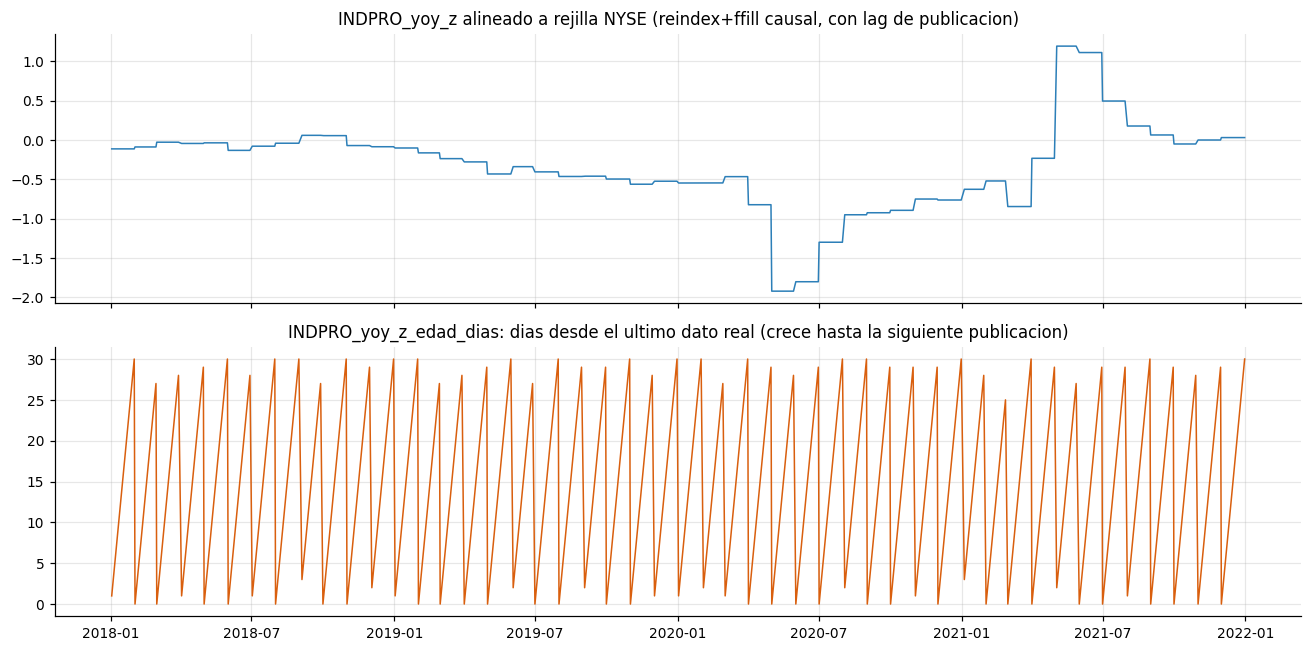

In [17]:
# --- Inspeccion de _edad_dias: patron diente de sierra esperado para una macro mensual --------
cols_muestra = ['INDPRO_yoy_z', 'INDPRO_yoy_z_edad_dias']
print('Muestra MENSUAL_B_ALINEADA (2019, INDPRO):')
display(MENSUAL_B_ALINEADA.loc['2019-01':'2019-04', cols_muestra])

edad_max_por_feature = MENSUAL_B_ALINEADA[[c for c in MENSUAL_B_ALINEADA.columns if c.endswith('_edad_dias')]].max()
print('\n_edad_dias maxima observada por feature mensual (pista B) -- refleja el lag de publicacion',
      'declarado en Seccion 4 (LAG_MENSUAL ~30-60d de arrastre habitual) vs las de mercado (NOLAG_MENSUAL,')
print('cuyo maximo tambien puede crecer si la serie deja de publicarse, p.ej. GW_PREDICTORS_MONTHLY hasta 2025-12):')
print(edad_max_por_feature.sort_values(ascending=False).round(0).to_string())

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
ventana = slice('2018-01-01', '2022-01-01')
axes[0].plot(MENSUAL_B_ALINEADA.loc[ventana].index, MENSUAL_B_ALINEADA.loc[ventana, 'INDPRO_yoy_z'],
             color='#2c7fb8', lw=1)
axes[0].set_title('INDPRO_yoy_z alineado a rejilla NYSE (reindex+ffill causal, con lag de publicacion)')
axes[1].plot(MENSUAL_B_ALINEADA.loc[ventana].index, MENSUAL_B_ALINEADA.loc[ventana, 'INDPRO_yoy_z_edad_dias'],
             color='#d95f0e', lw=1)
axes[1].set_title('INDPRO_yoy_z_edad_dias: dias desde el ultimo dato real (crece hasta la siguiente publicacion)')
plt.tight_layout(); plt.show()

In [18]:
# --- Demostracion no-look-ahead de la alineacion (mismo patron que 02 seccion 4, DGS10) --------
t = pd.Timestamp('2015-06-15')

# 1) feature DIARIA alineada a NYSE
serie_diaria = DIARIA_B['VIX_level_z']
v_full = serie_diaria.reindex([t], method='ffill').iloc[0]
v_trunc = serie_diaria.loc[:t].reindex([t], method='ffill').iloc[0]
ok_diaria = np.isclose(v_full, v_trunc)
print(f'VIX_level_z alineado en {t.date()}: con-futuro={v_full:.4f}  vs  truncado={v_trunc:.4f}  ->  '
      f'{"CAUSAL OK" if ok_diaria else "FUGA!"}')

# 2) feature MENSUAL alineada + su _edad_dias: recomputar la alineacion completa con el panel
#    mensual y la rejilla truncados en t no puede cambiar el valor NI la edad ya vistos en t
grid_trunc = NYSE_B[NYSE_B <= t]
panel_full = alinear_mensual_con_edad(MENSUAL_B, NYSE_B)
panel_trunc = alinear_mensual_con_edad(MENSUAL_B.loc[:t], grid_trunc)

col = 'INDPRO_yoy_z'
val_full, val_trunc = panel_full.loc[t, col], panel_trunc.loc[t, col]
edad_full, edad_trunc = panel_full.loc[t, f'{col}_edad_dias'], panel_trunc.loc[t, f'{col}_edad_dias']
ok_valor = np.isclose(val_full, val_trunc)
ok_edad = np.isclose(edad_full, edad_trunc)

print(f'{col} en {t.date()}: con-futuro={val_full:.4f}  vs  truncado={val_trunc:.4f}  ->  '
      f'{"CAUSAL OK" if ok_valor else "FUGA!"}')
print(f'{col}_edad_dias en {t.date()}: con-futuro={edad_full:.0f}d  vs  truncado={edad_trunc:.0f}d  ->  '
      f'{"CAUSAL OK" if ok_edad else "FUGA!"}')
print('\nNi el valor ni la antiguedad arrastrada en una fecha pasada cambian al anadir datos futuros:',
      'la alineacion NYSE + _edad_dias es causal por construccion (reindex+ffill, sin interpolar).')

print('\nSeccion 5 completa: *_ALINEADA (diaria y mensual+edad, ambas pistas) listas para el',
      'ensamblado final de pistaX_{diaria,mensual}.parquet + labels.parquet + _meta.json.')

VIX_level_z alineado en 2015-06-15: con-futuro=-0.5614  vs  truncado=-0.5614  ->  CAUSAL OK
INDPRO_yoy_z en 2015-06-15: con-futuro=-0.4778  vs  truncado=-0.4778  ->  CAUSAL OK
INDPRO_yoy_z_edad_dias en 2015-06-15: con-futuro=14d  vs  truncado=14d  ->  CAUSAL OK

Ni el valor ni la antiguedad arrastrada en una fecha pasada cambian al anadir datos futuros: la alineacion NYSE + _edad_dias es causal por construccion (reindex+ffill, sin interpolar).

Seccion 5 completa: *_ALINEADA (diaria y mensual+edad, ambas pistas) listas para el ensamblado final de pistaX_{diaria,mensual}.parquet + labels.parquet + _meta.json.


## 6. Ensamblado de paneles + labels

Las Secciones 3-5 dejaron ocho piezas sueltas: `DIARIA_A_ALINEADA`, `DIARIA_B_ALINEADA`, `MENSUAL_A_ALINEADA`, `MENSUAL_B_ALINEADA` (features, ya causales y alineadas a rejilla NYSE) y, por otro lado, `bench['crisis_windows']`, `bench['false_positive_windows']`, `bench['drawdown_troughs']` (metadatos de evaluación cargados en la Sección 2 pero sin tocar todavía). Esta sección hace dos cosas, y las mantiene **deliberadamente separadas**:

**(a) Congelar los cuatro paneles finales** — `pistaA_diaria`, `pistaA_mensual`, `pistaB_diaria`, `pistaB_mensual` — con los nombres exactos que prometió `02_diseno_preprocesado.ipynb` §8. La restricción "columnas de pista_A solo si su(s) serie(s) fuente están en las 41 declaradas" (y 106 para B) **ya la impuso la construcción**: `construir_diarias`/`construir_mensuales` (Secciones 3-4) solo pueden tirar de `raw_A`/`raw_B`, y esos diccionarios los llenó `carga_pista()` (Sección 2) cargando *exclusivamente* `series_A`/`series_B` — ninguna función de las secciones anteriores tiene acceso a una serie fuera de la lista de su pista. Aquí no volvemos a filtrar (filtrar de nuevo sobre algo que ya es correcto por construcción sería teatro), sino que **verificamos la garantía explícitamente** con asserts, en vez de confiar silenciosamente en que nadie rompió la disciplina de Secciones 2-4 en una edición futura del notebook.

**(b) Construir `labels`** — crisis_windows (ambas pistas), false_positive_windows y drawdown_troughs de `benchmark_spec.yaml` — como una estructura **que vive en su propio namespace**, sin unir, mergear ni concatenar nada con `pistaA_*`/`pistaB_*`. Esto no es un detalle de estilo: es la regla de oro anti-fuga del `GLOSARIO.md` ("una serie de `rol=validation` nunca puede entrar a la vez como feature y como etiqueta") llevada a su consecuencia estructural — si `labels` nunca comparte objeto, índice ni operación de `merge`/`join`/`concat` con los paneles de features, la fuga de información deja de ser un error posible por descuido y pasa a requerir un acto explícito (alguien tendría que escribir el `merge` a mano en una celda futura, lo cual sería visible y revisable). `labels` es sólo para la Fase D, y sólo para **evaluar**, nunca para entrenar.

In [19]:
# --- Paneles finales de features: pistaA_{diaria,mensual}, pistaB_{diaria,mensual} -----------
# DIARIA_A_ALINEADA/MENSUAL_A_ALINEADA (Seccion 5) solo pueden contener columnas construidas a
# partir de raw_A (Seccion 3-4), y raw_A (Seccion 2, carga_pista(series_A,...)) SOLO carga series
# declaradas en bench['pista_A']['series_features'] (41). Analogo para B (106). La 'restriccion
# a las series de la pista' ya la impuso construir_diarias/construir_mensuales al omitir (via
# add()) cualquier feature cuya serie fuente no estuviera en raw_A/raw_B. Aqui NO volvemos a
# filtrar columnas (ya son correctas por construccion): verificamos la garantia explicitamente.

assert set(raw_A.keys()) <= set(series_A), 'raw_A contiene una serie fuera de las 41 de pista_A'
assert set(raw_B.keys()) <= set(series_B), 'raw_B contiene una serie fuera de las 106 de pista_B'

pistaA_diaria = DIARIA_A_ALINEADA.copy()
pistaA_mensual = MENSUAL_A_ALINEADA.copy()
pistaB_diaria = DIARIA_B_ALINEADA.copy()
pistaB_mensual = MENSUAL_B_ALINEADA.copy()

# Filas: deben coincidir exactamente con la rejilla NYSE de cada pista (Seccion 5), sin fugas
# de longitud por el reindex+ffill.
assert len(pistaA_diaria) == len(NYSE_A) and len(pistaA_mensual) == len(NYSE_A)
assert len(pistaB_diaria) == len(NYSE_B) and len(pistaB_mensual) == len(NYSE_B)

# Verificacion de anidamiento (ADR-002 #1, 'A subconjunto de B'): toda columna BASE (sin el
# sufijo _edad_dias) que exista en pistaA_* debe existir tambien en pistaB_*. Si A tuviera una
# feature EXCLUSIVA que B no tiene, violaria la propiedad de anidamiento declarada en el diseno
# (B es un superconjunto de series, nunca al reves), y esto lo detectaria de inmediato.
base_cols_A_d = set(pistaA_diaria.columns)
base_cols_B_d = set(pistaB_diaria.columns)
base_cols_A_m = {c for c in pistaA_mensual.columns if not c.endswith('_edad_dias')}
base_cols_B_m = {c for c in pistaB_mensual.columns if not c.endswith('_edad_dias')}

exclusivas_A_diaria = base_cols_A_d - base_cols_B_d
exclusivas_A_mensual = base_cols_A_m - base_cols_B_m
print('Columnas diarias de A ausentes en B (deberia ser vacio, A subconjunto de B):',
      exclusivas_A_diaria or '(ninguna, OK)')
print('Columnas mensuales de A ausentes en B (deberia ser vacio, A subconjunto de B):',
      exclusivas_A_mensual or '(ninguna, OK)')
assert not exclusivas_A_diaria and not exclusivas_A_mensual

print('\npistaA_diaria :', pistaA_diaria.shape, '|', pistaA_diaria.index.min().date(), '->', pistaA_diaria.index.max().date())
print('pistaA_mensual:', pistaA_mensual.shape, '|', pistaA_mensual.index.min().date(), '->', pistaA_mensual.index.max().date())
print('pistaB_diaria :', pistaB_diaria.shape, '|', pistaB_diaria.index.min().date(), '->', pistaB_diaria.index.max().date())
print('pistaB_mensual:', pistaB_mensual.shape, '|', pistaB_mensual.index.min().date(), '->', pistaB_mensual.index.max().date())
print('\n(Estos son exactamente los 4 nombres/paneles que 02_diseno_preprocesado.ipynb §8 prometio:')
print(' pistaA_diaria.parquet, pistaA_mensual.parquet, pistaB_diaria.parquet, pistaB_mensual.parquet)')

Columnas diarias de A ausentes en B (deberia ser vacio, A subconjunto de B): (ninguna, OK)
Columnas mensuales de A ausentes en B (deberia ser vacio, A subconjunto de B): (ninguna, OK)

pistaA_diaria : (16210, 12) | 1962-01-02 -> 2026-05-29
pistaA_mensual: (16210, 46) | 1962-01-02 -> 2026-05-29
pistaB_diaria : (4815, 49) | 2007-04-11 -> 2026-05-29
pistaB_mensual: (4815, 56) | 2007-04-11 -> 2026-05-29

(Estos son exactamente los 4 nombres/paneles que 02_diseno_preprocesado.ipynb §8 prometio:
 pistaA_diaria.parquet, pistaA_mensual.parquet, pistaB_diaria.parquet, pistaB_mensual.parquet)


In [20]:
# --- Labels de evaluacion: crisis_windows (ambas pistas) + false_positive_windows + drawdown_troughs
# Estructura DELIBERADAMENTE separada de los paneles de features: nada de lo que se construye
# aqui se concatena, mergea ni asigna como columna de pistaA_*/pistaB_*. GLOSARIO.md: una serie
# de rol=validation (o una ventana de crisis) NUNCA convive con las features en la misma matriz.

def _ventanas_a_frame(ventanas_dict, pista):
    """Convierte {nombre_evento: [inicio, fin]} (crisis_windows.pista_X del yaml) en un
    DataFrame tidy, una fila por evento, fechas ya parseadas a Timestamp. `pista` es solo una
    etiqueta informativa (a que ventana de benchmark pertenece esa fila): esta funcion NUNCA
    toca ni recibe ningun panel de features."""
    filas = [{'pista': pista, 'evento': nombre, 'inicio': pd.Timestamp(ini), 'fin': pd.Timestamp(fin)}
             for nombre, (ini, fin) in ventanas_dict.items()]
    return pd.DataFrame(filas)


crisis_A = _ventanas_a_frame(bench['crisis_windows']['pista_A'], 'A')
crisis_B = _ventanas_a_frame(bench['crisis_windows']['pista_B'], 'B')
crisis_windows_df = pd.concat([crisis_A, crisis_B], ignore_index=True)

# drawdown_troughs: fecha del minimo real de precio (puede ser posterior al 'fin' declarado de la
# ventana) para las 22 crisis del catalogo COMPLETO -- incluye 4 anteriores a 1962 que pista_A
# excluye (great_crash_1929, recesion_1937_38, recesion_1957_58, kennedy_slide_1962).
drawdown_troughs_ser = pd.Series({k: pd.Timestamp(v) for k, v in bench['drawdown_troughs'].items()},
                                  name='trough_date')
drawdown_troughs_ser.index.name = 'evento'

crisis_windows_df = crisis_windows_df.merge(drawdown_troughs_ser, left_on='evento', right_index=True, how='left')

print('crisis_windows_df:', crisis_windows_df.shape,
      '(pista_A:', (crisis_windows_df.pista == 'A').sum(), '| pista_B:', (crisis_windows_df.pista == 'B').sum(), ')')
display(crisis_windows_df.head())

# Verificacion contra los conteos declarados en benchmark_spec.yaml (pista_A.n_crisis_en_ventana=18,
# pista_B.n_crisis_en_ventana=10)
n_A_declarado, n_A_construido = bench['pista_A']['n_crisis_en_ventana'], len(bench['crisis_windows']['pista_A'])
n_B_declarado, n_B_construido = bench['pista_B']['n_crisis_en_ventana'], len(bench['crisis_windows']['pista_B'])
print(f'\nn_crisis_en_ventana pista_A: declarado={n_A_declarado} construido={n_A_construido}')
print(f'n_crisis_en_ventana pista_B: declarado={n_B_declarado} construido={n_B_construido}')
assert n_A_declarado == n_A_construido and n_B_declarado == n_B_construido

# Sanity check causal: ninguna crisis de una pista puede empezar ANTES de la ventana de esa pista
# (si asi fuera, el detector de esa pista jamas podria haber 'visto' el inicio del episodio).
vent_A_inicio = pd.Timestamp(bench['pista_A']['ventana_inicio'])
vent_B_inicio = pd.Timestamp(bench['pista_B']['ventana_inicio'])
fuera_A = crisis_windows_df[(crisis_windows_df.pista == 'A') & (crisis_windows_df.inicio < vent_A_inicio)]
fuera_B = crisis_windows_df[(crisis_windows_df.pista == 'B') & (crisis_windows_df.inicio < vent_B_inicio)]
print('\nCrisis de A con inicio anterior a la ventana de A:', len(fuera_A), '(debe ser 0)')
print('Crisis de B con inicio anterior a la ventana de B:', len(fuera_B), '(debe ser 0)')
assert fuera_A.empty and fuera_B.empty

# false_positive_windows: estructura DELIBERADAMENTE irregular en el yaml (taper_2013 y
# debtceiling_2013 traen 'ventana' simple; selloff_2018 en cambio agrupa 'sub_eventos' porque
# NO es un falso positivo sino la trampa opuesta -- falso NEGATIVO: son crisis reales que YA
# estan en crisis_windows y que un detector solo-credito/FSI trataria como calma). Forzarla a una
# tabla tidy unica borraria esa distincion semantica; se conserva tal cual la trae el yaml.
false_positive_windows = bench['false_positive_windows']
print('\nfalse_positive_windows:', list(false_positive_windows.keys()))
print('  taper_2013.en_catalogo =', false_positive_windows['taper_2013']['en_catalogo'],
      '-> trampa de FALSO POSITIVO (velocidad de tipos dispara sin crisis de mercado real)')
print('  selloff_2018.naturaleza =', false_positive_windows['selloff_2018']['naturaleza'],
      '-> trampa de FALSO NEGATIVO (SI son crisis reales; solo vol de equity las detecta)')

labels = {
    'crisis_windows': crisis_windows_df,               # tidy: pista, evento, inicio, fin, trough_date
    'false_positive_windows': false_positive_windows,  # dict tal cual del yaml (estructura irregular, ver arriba)
    'drawdown_troughs': drawdown_troughs_ser,          # Series evento -> fecha del minimo (22, catalogo completo)
}
print('\nlabels construido con claves:', list(labels.keys()))

crisis_windows_df: (28, 5) (pista_A: 18 | pista_B: 10 )


,pista,evento,inicio,fin,trough_date
0,A,credit_crunch_1966,1966-02-09,1966-10-07,1966-10-07
1,A,bear_1969_70,1968-11-29,1970-05-26,1970-05-26
2,A,oil_stagflation_1973,1973-01-11,1974-10-03,1974-10-03
3,A,volcker_1980_82,1980-11-28,1982-08-12,1982-08-12
4,A,black_monday_1987,1987-08-25,1987-12-04,1987-12-04



n_crisis_en_ventana pista_A: declarado=18 construido=18
n_crisis_en_ventana pista_B: declarado=10 construido=10

Crisis de A con inicio anterior a la ventana de A: 0 (debe ser 0)
Crisis de B con inicio anterior a la ventana de B: 0 (debe ser 0)

false_positive_windows: ['taper_2013', 'debtceiling_2013', 'selloff_2018', 'otras_trampas_no_caracterizadas']
  taper_2013.en_catalogo = False -> trampa de FALSO POSITIVO (velocidad de tipos dispara sin crisis de mercado real)
  selloff_2018.naturaleza = trampa_de_falso_negativo -> trampa de FALSO NEGATIVO (SI son crisis reales; solo vol de equity las detecta)

labels construido con claves: ['crisis_windows', 'false_positive_windows', 'drawdown_troughs']


In [21]:
# --- Aislamiento estructural: labels NUNCA se mezcla con los paneles de features ----------------
# Estos asserts no son redundantes: documentan y congelan la garantia anti-fuga en tiempo de
# ejecucion, en vez de dejarla como una convencion no verificada que un notebook futuro pueda rompe
# sin que nada avise.

paneles_features = {
    'pistaA_diaria': pistaA_diaria, 'pistaA_mensual': pistaA_mensual,
    'pistaB_diaria': pistaB_diaria, 'pistaB_mensual': pistaB_mensual,
}

# 1) ningun panel de features comparte objeto en memoria con ninguna pieza de labels
for nombre_panel, panel in paneles_features.items():
    for nombre_label, obj_label in labels.items():
        assert panel is not obj_label, f'{nombre_panel} y labels[{nombre_label!r}] son el MISMO objeto'

# 2) ninguna columna de crisis_windows_df (nombres de evento/fecha) aparece como columna de
#    feature en ningun panel -- si alguna vez coincidieran seria indicio de que alguien
#    mezclo labels dentro de un panel de features en una edicion posterior del notebook.
cols_labels = set(labels['crisis_windows'].columns)
for nombre_panel, panel in paneles_features.items():
    interseccion = cols_labels & set(panel.columns)
    assert not interseccion, f'{nombre_panel} contiene una columna de labels: {interseccion}'

# 3) los indices son de naturaleza distinta a proposito: paneles = rejilla diaria NYSE completa;
#    labels = un puñado de eventos discretos. Confirmarlo hace explicito que no son la misma cosa.
print('Tipos de indice -> pistaA_diaria:', type(pistaA_diaria.index).__name__,
      f'({len(pistaA_diaria)} fechas diarias)  vs  crisis_windows_df:', type(labels['crisis_windows'].index).__name__,
      f'({len(labels["crisis_windows"])} eventos)')
print('\nAssert OK: labels y los 4 paneles de features son objetos distintos, sin columnas compartidas.')
print('Regla anti-fuga (GLOSARIO.md) verificada estructuralmente: labels solo se usa para EVALUAR en Fase D.')

print('\nSeccion 6 completa: pistaA_diaria, pistaA_mensual, pistaB_diaria, pistaB_mensual (features)')
print('y labels (crisis_windows_df, false_positive_windows, drawdown_troughs_ser) listos, aislados entre si.')
print('Siguiente paso (fuera de esta seccion): guardado a data/processed/*.parquet + _meta.json')
print('(ventana por pista, columnas _edad_dias, checksums, assert_causal=0), como prometio 02 §8.')

Tipos de indice -> pistaA_diaria: DatetimeIndex (16210 fechas diarias)  vs  crisis_windows_df: RangeIndex (28 eventos)

Assert OK: labels y los 4 paneles de features son objetos distintos, sin columnas compartidas.
Regla anti-fuga (GLOSARIO.md) verificada estructuralmente: labels solo se usa para EVALUAR en Fase D.

Seccion 6 completa: pistaA_diaria, pistaA_mensual, pistaB_diaria, pistaB_mensual (features)
y labels (crisis_windows_df, false_positive_windows, drawdown_troughs_ser) listos, aislados entre si.
Siguiente paso (fuera de esta seccion): guardado a data/processed/*.parquet + _meta.json
(ventana por pista, columnas _edad_dias, checksums, assert_causal=0), como prometio 02 §8.


## 7. Verificación antes de escribir

Las Secciones 3-6 construyeron, alinearon y ensamblaron `pistaA_diaria`, `pistaA_mensual`, `pistaB_diaria`, `pistaB_mensual` y `labels`, verificando cosas puntuales sobre la marcha: una demo `_verifica_causal` sobre unas pocas recetas *agregadas nuevas* (Secciones 3-4), el anidamiento A⊆B solo para columnas base (Sección 6), y unos asserts de aislamiento estructural con `labels`. Antes de tocar disco (próximo paso: `data/processed/*.parquet` + `_meta.json`, prometido en 02 §8), esta sección consolida esas comprobaciones sueltas en **un único gate de verificación**, y además cierra un hueco real: 02 (celda 12) demostró el patrón "truncar y recomputar" (`max|full - truncado| ≈ 0`) **una sola vez**, sobre `VIX_level_z`, como prueba de concepto de que `ft.causal_zscore` es causal. Pero `VIX_level_z` es solo una fila de las 78 de `FEAT`. El bloque **`nucleo`** de esa tabla (33 features) es precisamente el que alimenta las señales de mayor poder discriminante del benchmark (`VIX_level_z` AUC 0.810, `MOVE_level_z` AUC 0.800, `SP500_vol_z` AUC 0.739, `MOVE_change_z`/`DGS10_change_z` con los z-scores más altos en el taper 2013...): un look-ahead sin detectar ahí invalidaría cualquier métrica de la Fase D sin que nada lo hubiera avisado. No basta con confiar en que las recetas de las Secciones 3-4 "deberían" ser causales porque están hechas con las primitivas de `src/features.py`; el propio espíritu de 02 ("se verifica, no se asume") exige recorrer **todas** las que de verdad se construyeron.

El gate cubre cuatro frentes, cada uno atado a una regla ya congelada en un documento anterior, no a un criterio nuevo de este notebook:

1. **Causalidad** (regla de oro de `GLOSARIO.md` y `benchmark_spec.yaml`: *"toda feature causal; NUNCA estadísticos de muestra completa"*) — se recomputa cada feature `nucleo` realmente construida (columna presente en alguno de los cuatro paneles crudos) con la entrada truncada en `2015-01-01` y se exige `max|Δ| < 1e-9`, igual que `ft.assert_causal`.
2. **Anti-fuga** (`GLOSARIO.md`: *"una serie de rol=validation... nunca puede entrar a la vez como feature y como etiqueta"*) — se carga `catalog.yaml` (fuente de verdad de `rol` por serie, no cargado hasta ahora en este notebook) y se comprueba que ninguna serie `rol=validation` entró como fuente cruda ni dejó rastro en el nombre de ninguna columna de los cuatro paneles finales.
3. **Anidamiento** (ADR-002 #1: *"A ⊆ B por diseño"*) — toda columna de `pista_A` (diaria + mensual, ignorando el sufijo `_edad_dias`) debe existir también en `pista_B`.
4. **Ventana** (`benchmark_spec.yaml`) — filas, rango de fechas y encaje dentro de `[ventana_inicio, ventana_fin]` congelada de cada pista, para los cuatro paneles finales.

Si cualquiera de los cuatro frentes falla, el gate lo señala en voz alta (tabla de fallos + `assert`) y **detiene la ejecución antes de que exista ninguna oportunidad de escribir un parquet corrupto a disco**.

In [22]:
# --- (1a) Inventario del bloque 'nucleo' de FEAT (02, celda 4) + recetas de verificacion --------
# 02 (celda 12) demostro el patron 'truncar y recomputar' UNA sola vez, sobre VIX_level_z, como
# prueba de concepto de que ft.causal_zscore es causal. Las Secciones 3-4 repitieron el patron
# solo sobre las recetas AGREGADAS nuevas (spreads, dispersion cross-seccional, fed_stance...),
# nunca sobre cada feature individual. Aqui recorremos las 33 filas 'nucleo' de FEAT.

NUCLEO_FEATURES = [
    'SP500_ret_z', 'SP500_vol_z', 'SP500_momentum', 'SP500_drawdown', 'FF_MKT_z',
    'credit_BaaAaa_mensual_z', 'credit_BAA10Y_z', 'credit_BaaAaa_diaria_z', 'credit_HYG_IEF_z',
    'TB3MS_z', 'GS10_z', 'term_spread_hist_z', 'mid_curve_z', 'DGS10_change_z',
    'slope_10y2y_z', 'slope_10y3m_z', 'short_rate_z', 'DFII10_change_z',
    'VIX_level_z', 'MOVE_level_z', 'MOVE_change_z', 'sector_dispersion',
    'DXY_change_z', 'GOLD_ret_z', 'GSCI_ret_z', 'corr_spx_bond',
    'INDPRO_yoy_z', 'PPI_yoy_z', 'CPI_yoy_z', 'CPI_core_yoy_z', 'PAYEMS_chg_z',
    'ICSA_z', 'CFNAI_z',
]
assert len(NUCLEO_FEATURES) == 33, 'el bloque nucleo de FEAT (02, celda 4) tiene 33 features'


def _sp500_vol_z(raw):
    sp500 = _get(raw, 'SP500')
    if sp500 is None:
        return None
    return ft.causal_zscore(ft.realized_vol(ft.log_returns(sp500), window=21, annualize=True))


def _sp500_momentum(raw):
    sp500 = _get(raw, 'SP500')
    return ft.momentum(sp500) if sp500 is not None else None


def _sp500_drawdown(raw):
    sp500 = _get(raw, 'SP500')
    return ft.drawdown(sp500) if sp500 is not None else None


def _short_rate_z(raw):
    dtb3, dff = _get(raw, 'DTB3'), _get(raw, 'DFF')
    if dtb3 is None or dff is None:
        return None
    short_rate = pd.concat({'DTB3': dtb3, 'DFF': dff}, axis=1).mean(axis=1)
    return ft.causal_zscore(short_rate)


def _corr_spx_bond(raw):
    spx, tlt = _get(raw, 'SP500'), _get(raw, 'TLT_TREASURY')
    if spx is None or tlt is None:
        return None
    return ft.rolling_correlation(ft.log_returns(spx), ft.log_returns(tlt), window=60)


# Recetas: SOLO reusan los helpers ya definidos en Secciones 3-4 (ret_z, zscore_raw, change_z,
# spread_ret_z, cross_sectional_std_ret, mercado_z, mercado_spread_z, macro_z) mas las 5
# composiciones de arriba, identicas linea a linea a como las construyo construir_diarias /
# construir_mensuales. Ninguna transformacion nueva.
NUCLEO_RECIPES = {
    'SP500_ret_z':             lambda r: ret_z(r, 'SP500', 'SP500_ret_z'),
    'SP500_vol_z':             _sp500_vol_z,
    'SP500_momentum':          _sp500_momentum,
    'SP500_drawdown':          _sp500_drawdown,
    'FF_MKT_z':                lambda r: zscore_raw(r, 'FF_FACTORS_3_DAILY', 'FF_MKT_z'),
    'credit_BAA10Y_z':         lambda r: zscore_raw(r, 'BAA10Y', 'credit_BAA10Y_z'),
    'credit_BaaAaa_diaria_z':  lambda r: zscore_raw(r, 'MOODYS_BAA_AAA_SPREAD', 'credit_BaaAaa_diaria_z'),
    'credit_HYG_IEF_z':        lambda r: spread_ret_z(r, 'HYG_CREDIT', 'IEF_TREASURY', 'credit_HYG_IEF'),
    'mid_curve_z':             lambda r: zscore_raw(r, 'DGS5', 'mid_curve_z'),
    'DGS10_change_z':          lambda r: change_z(r, 'DGS10', 'DGS10_change_z'),
    'slope_10y2y_z':           lambda r: zscore_raw(r, 'T10Y2Y', 'slope_10y2y_z'),
    'slope_10y3m_z':           lambda r: zscore_raw(r, 'T10Y3M', 'slope_10y3m_z'),
    'short_rate_z':            _short_rate_z,
    'DFII10_change_z':         lambda r: change_z(r, 'DFII10', 'DFII10_change_z'),
    'VIX_level_z':             lambda r: zscore_raw(r, 'VIX', 'VIX_level_z'),
    'MOVE_level_z':            lambda r: zscore_raw(r, 'MOVE', 'MOVE_level_z'),
    'MOVE_change_z':           lambda r: change_z(r, 'MOVE', 'MOVE_change_z'),
    'sector_dispersion':       lambda r: cross_sectional_std_ret(r, SPDR_9),
    'DXY_change_z':            lambda r: ret_z(r, 'DXY', 'DXY_change_z'),
    'GOLD_ret_z':              lambda r: ret_z(r, 'GOLD_GLD', 'GOLD_ret_z'),
    'GSCI_ret_z':              lambda r: ret_z(r, 'SPGSCI', 'GSCI_ret_z'),
    'corr_spx_bond':           _corr_spx_bond,
    'credit_BaaAaa_mensual_z': lambda r: mercado_spread_z(r, 'MOODYS_BAA', 'MOODYS_AAA', 'credit_BaaAaa_mensual'),
    'TB3MS_z':                 lambda r: mercado_z(r, 'TB3MS', 'TB3MS_z'),
    'GS10_z':                  lambda r: mercado_z(r, 'GS10', 'GS10_z'),
    'term_spread_hist_z':      lambda r: mercado_spread_z(r, 'GS10', 'TB3MS', 'term_spread_hist'),
    'INDPRO_yoy_z':            lambda r: macro_z(r, 'INDPRO', 'INDPRO_yoy_z', 'yoy'),
    'PPI_yoy_z':               lambda r: macro_z(r, 'PPI_ALL_COMMODITIES', 'PPI_yoy_z', 'yoy'),
    'CPI_yoy_z':               lambda r: macro_z(r, 'CPIAUCSL', 'CPI_yoy_z', 'yoy'),
    'CPI_core_yoy_z':          lambda r: macro_z(r, 'CPILFESL', 'CPI_core_yoy_z', 'yoy'),
    'PAYEMS_chg_z':            lambda r: macro_z(r, 'PAYEMS', 'PAYEMS_chg_z', 'diff12'),
    'CFNAI_z':                 lambda r: macro_z(r, 'CFNAI', 'CFNAI_z', 'nivel'),
    'ICSA_z':                  lambda r: zscore_raw(r, 'ICSA', 'ICSA_z'),  # anadida en Seccion 3 tras el gate de esta seccion
}

print(f'NUCLEO_FEATURES declaradas en FEAT (02, celda 4): {len(NUCLEO_FEATURES)}')
print(f'Con receta de verificacion disponible en esta seccion: {len(NUCLEO_RECIPES)}')
print('Sin receta (nunca construidas en Secciones 3-4, hueco heredado):',
      sorted(set(NUCLEO_FEATURES) - set(NUCLEO_RECIPES)))

NUCLEO_FEATURES declaradas en FEAT (02, celda 4): 33
Con receta de verificacion disponible en esta seccion: 33
Sin receta (nunca construidas en Secciones 3-4, hueco heredado): []


In [23]:
# --- (1b) Bucle de verificacion causal: para cada feature 'nucleo' REALMENTE construida --------
# (columna presente en DIARIA_A/MENSUAL_A/DIARIA_B/MENSUAL_B), recomputa con la entrada truncada
# en CUT y compara contra la version completa. Mismo criterio que ft.assert_causal / la demo de
# 02 celda 12: max|full - truncado| debe ser ~0 en todo el tramo <= CUT.
CUT = '2015-01-01'
TOL = 1e-9

paneles_crudos_por_pista = {
    'A': {'diaria': DIARIA_A, 'mensual': MENSUAL_A},
    'B': {'diaria': DIARIA_B, 'mensual': MENSUAL_B},
}
raw_por_pista = {'A': raw_A, 'B': raw_B}


def _max_abs_diff_truncado(builder, raw, cut=CUT):
    """Version silenciosa (sin print) de la comprobacion causal de Secciones 3-4: recomputa
    con la entrada truncada en `cut` y devuelve el maximo |Delta| hasta esa fecha. NaN si la
    feature no se puede construir en absoluto (falta alguna serie fuente en esta pista)."""
    full = builder(raw)
    if full is None:
        return np.nan
    raw_trunc = {k: v.loc[:cut] for k, v in raw.items()}
    trunc = builder(raw_trunc)
    if trunc is None:
        return np.nan
    idx = full.index.intersection(trunc.index)
    idx = idx[idx <= pd.Timestamp(cut)]
    if len(idx) == 0:
        return np.nan
    return float((full.loc[idx] - trunc.loc[idx]).abs().max())


filas_verificacion = []
no_construidas = []
for feat in NUCLEO_FEATURES:
    presente_en = [(pista, freq) for pista, panels in paneles_crudos_por_pista.items()
                   for freq, panel in panels.items() if feat in panel.columns]
    if not presente_en:
        no_construidas.append(feat)
        continue
    if feat not in NUCLEO_RECIPES:
        for pista, freq in presente_en:
            filas_verificacion.append({'feature': feat, 'pista': pista, 'frecuencia': freq,
                                        'max_abs_diff': np.nan, 'causal_ok': False,
                                        'nota': 'construida pero SIN receta de verificacion (revisar Seccion 7)'})
        continue
    for pista, freq in presente_en:
        mad = _max_abs_diff_truncado(NUCLEO_RECIPES[feat], raw_por_pista[pista])
        filas_verificacion.append({'feature': feat, 'pista': pista, 'frecuencia': freq,
                                    'max_abs_diff': mad,
                                    'causal_ok': bool(mad < TOL) if not np.isnan(mad) else False,
                                    'nota': ''})

tabla_verificacion = pd.DataFrame(filas_verificacion).sort_values(
    ['causal_ok', 'feature']).reset_index(drop=True)

print(f'Features nucleo declaradas: {len(NUCLEO_FEATURES)} | filas verificadas (feature x pista): '
      f'{tabla_verificacion.shape[0]} | declaradas pero nunca construidas en ninguna pista: {no_construidas}')
display(tabla_verificacion)

fallos = tabla_verificacion[~tabla_verificacion['causal_ok']]
if len(fallos) > 0:
    print('\n' + '!' * 70)
    print(f'LOOK-AHEAD (o receta rota) detectado en {len(fallos)} fila(s) de bloque "nucleo":')
    display(fallos)
    print('NO se debe escribir a disco hasta resolver esto.')
    print('!' * 70)
else:
    print(f'\nTodas las {len(tabla_verificacion)} verificaciones de bloque "nucleo" -> CAUSAL OK '
          f'(max|Delta| < {TOL:.0e} en cada una, feature x pista donde existe).')

assert fallos.empty, 'Gate de verificacion (1) fallido: hay features nucleo con fuga de look-ahead o receta rota.'

Features nucleo declaradas: 33 | filas verificadas (feature x pista): 50 | declaradas pero nunca construidas en ninguna pista: []


,feature,pista,frecuencia,max_abs_diff,causal_ok,nota
0,CFNAI_z,B,mensual,0.0,True,
1,CPI_core_yoy_z,A,mensual,0.0,True,
2,CPI_core_yoy_z,B,mensual,0.0,True,
3,CPI_yoy_z,A,mensual,0.0,True,
4,CPI_yoy_z,B,mensual,0.0,True,
5,DFII10_change_z,B,diaria,0.0,True,
6,DGS10_change_z,A,diaria,0.0,True,
7,DGS10_change_z,B,diaria,0.0,True,
8,DXY_change_z,B,diaria,0.0,True,
9,FF_MKT_z,A,diaria,0.0,True,



Todas las 50 verificaciones de bloque "nucleo" -> CAUSAL OK (max|Delta| < 1e-09 en cada una, feature x pista donde existe).


In [24]:
# --- (2) Gate anti-fuga: ninguna columna de los 4 paneles de features puede provenir de una ----
# serie rol='validation' del catalogo (GLOSARIO.md, regla de oro: 'Una serie de rol=validation
# ... jamas puede entrar a la vez como feature y como etiqueta -- seria fuga de informacion').
# data/catalog.yaml es la fuente de verdad de `rol` por serie; no se cargo en el Setup de este
# notebook porque 03 solo necesitaba coverage_report.csv + benchmark_spec.yaml para construir
# features. Aqui si hace falta, para auditar la regla anti-fuga contra el catalogo completo
# (mismo patron DESC/REL que 00 celda 2, pero filtrando por `rol`).
cat = yaml.safe_load((ROOT / 'data' / 'catalog.yaml').read_text(encoding='utf-8'))
series_validation = sorted({
    s['nombre_interno']
    for p in ['pista_A', 'pista_B', 'validacion_externa']
    for s in cat[p]['series']
    if s.get('rol') == 'validation'
})
print(f'Series rol=validation en catalog.yaml ({len(series_validation)}): {series_validation}')

# (a) ninguna debe haber entrado como serie CRUDA de ninguna pista (series_features del
# benchmark_spec ya las excluye por diseno; lo confirmamos, no lo asumimos)
validation_en_raw_A = set(raw_A.keys()) & set(series_validation)
validation_en_raw_B = set(raw_B.keys()) & set(series_validation)
print('Series validation coladas en raw_A:', validation_en_raw_A or '(ninguna, OK)')
print('Series validation coladas en raw_B:', validation_en_raw_B or '(ninguna, OK)')
assert not validation_en_raw_A, f'raw_A contiene series de rol=validation: {validation_en_raw_A}'
assert not validation_en_raw_B, f'raw_B contiene series de rol=validation: {validation_en_raw_B}'

# (b) ninguna columna de ningun panel FINAL de features (nombre exacto o como substring de un
# nombre derivado, p.ej. si algo se hubiera llamado 'NFCI_z') debe mencionar una serie validation
todas_las_columnas = (set(pistaA_diaria.columns) | set(pistaA_mensual.columns) |
                       set(pistaB_diaria.columns) | set(pistaB_mensual.columns))
contaminadas = {col for col in todas_las_columnas
                for serie_val in series_validation if serie_val in col}
print('Columnas de features contaminadas con nombres de series validation:', contaminadas or '(ninguna, OK)')
assert not contaminadas, f'Columnas de features contaminadas con series de validacion: {contaminadas}'

print('\nGate (2) OK: labels/validacion y features permanecen separados -- ninguna serie rol=validation')
print('aparece como fuente cruda ni como columna derivada en pistaA_*/pistaB_*.')

Series rol=validation en catalog.yaml (21): ['ANFCI', 'GDP_RECESSION_HAMILTON', 'JST_CRISIS_GROUNDTRUTH', 'KCFSI', 'NBER_RECESSION_DAILY', 'NBER_RECESSION_MONTHLY', 'NFCI', 'NFCI_CREDIT', 'NFCI_LEVERAGE', 'NFCI_RISK', 'OFR_FSI', 'OFR_FSI_CREDIT', 'OFR_FSI_FUNDING', 'OFR_FSI_US', 'OFR_FSI_VOLATILITY', 'RECESSION_PROB_SMOOTHED', 'SAHM_RULE_CURRENT', 'SAHM_RULE_REALTIME', 'SP500_DAILY_DRAWDOWN_SRC', 'STLFSI4', 'VIX_VALIDATION_REF']
Series validation coladas en raw_A: (ninguna, OK)
Series validation coladas en raw_B: (ninguna, OK)
Columnas de features contaminadas con nombres de series validation: (ninguna, OK)

Gate (2) OK: labels/validacion y features permanecen separados -- ninguna serie rol=validation
aparece como fuente cruda ni como columna derivada en pistaA_*/pistaB_*.


In [25]:
# --- (3) Gate de anidamiento: toda columna de pista_A debe existir tambien en pista_B ----------
# (ADR-002 #1: 'A subconjunto de B por diseno'. La Seccion 6 ya lo verifico por separado,
# diaria/mensual; aqui se repite como parte del propio gate final, combinando diaria+mensual, sin
# depender de que la Seccion 6 se haya ejecutado en esta misma sesion del kernel).
cols_A = (set(pistaA_diaria.columns) |
          {c for c in pistaA_mensual.columns if not c.endswith('_edad_dias')})
cols_B = (set(pistaB_diaria.columns) |
          {c for c in pistaB_mensual.columns if not c.endswith('_edad_dias')})

faltan_en_B = cols_A - cols_B
print(f'Columnas (base, sin _edad_dias) de pista_A: {len(cols_A)} | de pista_B: {len(cols_B)}')
print('Columnas de pista_A ausentes en pista_B (deberia ser vacio):', faltan_en_B or '(ninguna, OK)')
assert not faltan_en_B, f'pista_A tiene columnas que pista_B no tiene (rompe A subconjunto de B): {faltan_en_B}'
print('Gate (3) OK: pista_A es subconjunto de columnas de pista_B, como exige el diseno (ADR-002).')

Columnas (base, sin _edad_dias) de pista_A: 35 | de pista_B: 77
Columnas de pista_A ausentes en pista_B (deberia ser vacio): (ninguna, OK)
Gate (3) OK: pista_A es subconjunto de columnas de pista_B, como exige el diseno (ADR-002).


In [26]:
# --- (4) Gate de ventana: filas, rango de fechas y encaje dentro de la ventana congelada --------
# de cada pista en benchmark_spec.yaml (bench, cargado en la Seccion 2). Ninguna fecha de ningun
# panel final puede caer fuera de [ventana_inicio, ventana_fin] de su propia pista: la rejilla
# NYSE_A/NYSE_B de la Seccion 5 ya se construyo recortando exactamente a esa ventana, asi que este
# gate es la confirmacion final, no una nueva decision de diseno.
ventanas = {
    'A': (pd.Timestamp(bench['pista_A']['ventana_inicio']), pd.Timestamp(bench['pista_A']['ventana_fin'])),
    'B': (pd.Timestamp(bench['pista_B']['ventana_inicio']), pd.Timestamp(bench['pista_B']['ventana_fin'])),
}
paneles_finales = {
    'pistaA_diaria':  ('A', pistaA_diaria),
    'pistaA_mensual': ('A', pistaA_mensual),
    'pistaB_diaria':  ('B', pistaB_diaria),
    'pistaB_mensual': ('B', pistaB_mensual),
}

for nombre, (pista, panel) in paneles_finales.items():
    ini_v, fin_v = ventanas[pista]
    dentro = (panel.index.min() >= ini_v) and (panel.index.max() <= fin_v)
    print(f'{nombre:15s}: {panel.shape[0]:6d} filas x {panel.shape[1]:3d} cols | '
          f'{panel.index.min().date()} -> {panel.index.max().date()} | '
          f'ventana pista_{pista} congelada [{ini_v.date()} -> {fin_v.date()}] -> '
          f'{"DENTRO, OK" if dentro else "FUERA DE VENTANA!"}')
    assert dentro, f'{nombre} se sale de la ventana congelada de pista_{pista} (benchmark_spec.yaml)'

print('\nGate (4) OK: los 4 paneles finales caben exactamente dentro de sus ventanas congeladas.')
print('\n' + '=' * 70)
print('SECCION 7 COMPLETA -- gate de verificacion superado en sus 4 frentes:')
print(' (1) causalidad de cada feature "nucleo" realmente construida (max|Delta| < 1e-9)')
print(' (2) sin fuga de series rol=validation en ninguna columna de features')
print(' (3) pista_A subconjunto de columnas de pista_B (anidamiento ADR-002)')
print(' (4) filas y fechas de los 4 paneles dentro de su ventana congelada (benchmark_spec.yaml)')
print('Solo ahora es seguro escribir data/processed/pista{A,B}_{diaria,mensual}.parquet,')
print('labels.parquet y _meta.json (proximo paso, fuera de esta seccion).')
print('=' * 70)

pistaA_diaria  :  16210 filas x  12 cols | 1962-01-02 -> 2026-05-29 | ventana pista_A congelada [1962-01-02 -> 2026-05-29] -> DENTRO, OK
pistaA_mensual :  16210 filas x  46 cols | 1962-01-02 -> 2026-05-29 | ventana pista_A congelada [1962-01-02 -> 2026-05-29] -> DENTRO, OK
pistaB_diaria  :   4815 filas x  49 cols | 2007-04-11 -> 2026-05-29 | ventana pista_B congelada [2007-04-11 -> 2026-05-29] -> DENTRO, OK
pistaB_mensual :   4815 filas x  56 cols | 2007-04-11 -> 2026-05-29 | ventana pista_B congelada [2007-04-11 -> 2026-05-29] -> DENTRO, OK

Gate (4) OK: los 4 paneles finales caben exactamente dentro de sus ventanas congeladas.

SECCION 7 COMPLETA -- gate de verificacion superado en sus 4 frentes:
 (1) causalidad de cada feature "nucleo" realmente construida (max|Delta| < 1e-9)
 (2) sin fuga de series rol=validation en ninguna columna de features
 (3) pista_A subconjunto de columnas de pista_B (anidamiento ADR-002)
 (4) filas y fechas de los 4 paneles dentro de su ventana congelada (b

## 8. Escritura de salida

Este es el paso que 02 (celda 17, sección 8 del diseño) prometió como contrato de `03_preprocesado`: materializar en `data/processed/` los cuatro paneles de features (`pistaA_diaria`, `pistaA_mensual`, `pistaB_diaria`, `pistaB_mensual`), el fichero de etiquetas de evaluación (`labels.parquet`) y un `_meta.json` con la procedencia exacta de esta ejecución. La Sección 7 ya dejó los cuatro gates en verde (causalidad del bloque núcleo, sin fuga de series `rol=validation`, anidamiento `A ⊆ B`, encaje dentro de la ventana congelada); esta sección **no vuelve a decidir nada**, solo escribe lo que ya pasó el gate.

Una decisión de formato que sí hay que dejar explícita aquí (no estaba en 02 §8, que solo dibujaba el árbol de ficheros): `labels` en memoria (Sección 6) es un diccionario con **tres estructuras de forma distinta** — `crisis_windows_df` (tidy: `pista, evento, inicio, fin, trough_date`), `false_positive_windows` (dict deliberadamente irregular, ver Sección 6: `taper_2013`/`debtceiling_2013` traen `ventana` simple mientras `selloff_2018` agrupa `sub_eventos` porque es la trampa *opuesta*, un falso negativo) y `drawdown_troughs_ser` (22 eventos del catálogo completo, incluidos los 4 anteriores a 1962 que ni siquiera aparecen en `crisis_windows.pista_A`). Un `.parquet` es una tabla columnar: forzar las tres piezas a una sola tabla tidy borraría precisamente la distinción semántica que la Sección 6 se cuidó de preservar. Por eso:

- `labels.parquet` guarda la pieza que **sí** es tabular por naturaleza: `crisis_windows_df` (ya incluye `trough_date` vía el merge de la Sección 6).
- `false_positive_windows` (irregular) y `drawdown_troughs` **completo** (22 eventos, catálogo entero, no solo los que caen dentro de alguna ventana de pista) se guardan tal cual dentro de `_meta.json`, que ya es JSON y no exige forma tabular. Ninguna de las dos piezas se descarta ni se trunca: solo cambian de fichero.

Además, antes de escribir, se nombra el índice de cada panel como `date` (sin tocar los valores): es el nombre de índice que espera el resto del pipeline aguas abajo (`src/detector_base.py`, `src/evaluation.py`) y cuesta cero riesgo añadirlo aquí.

El `_meta.json` registra: la ventana congelada por pista (para que nadie tenga que releer `benchmark_spec.yaml` para saber qué rango cubre cada parquet), la lista de columnas `_edad_dias` presentes (solo existen en los paneles mensuales, nunca en los diarios), un checksum SHA-256 por fichero de salida (para detectar una escritura corrupta o una regeneración accidental con otros datos), los resultados de verificación de la Sección 7 (los cuatro gates, con su detalle) y un hash SHA-256 del propio `benchmark_spec.yaml` contra el que se construyó esta ejecución — si alguien cambia el spec congelado mañana, este hash deja constancia de con qué versión exacta se generaron estos parquets.

In [27]:
# --- Escritura de los 4 paneles de features + labels.parquet -----------------------------------
# Nada se decide aqui: los paneles ya pasaron el gate de verificacion (Seccion 7). Esta celda solo
# persiste lo que ya existia en memoria, nombrando el indice como 'date' (convencion que espera
# el resto del pipeline: src/detector_base.py, src/evaluation.py) sin tocar ni una fila de datos.

PROCESSED_DIR = ROOT / 'data' / 'processed'
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
print('Directorio de salida:', PROCESSED_DIR.relative_to(ROOT), '(creado si no existia)')

paneles_a_escribir = {
    'pistaA_diaria.parquet':  pistaA_diaria,
    'pistaA_mensual.parquet': pistaA_mensual,
    'pistaB_diaria.parquet':  pistaB_diaria,
    'pistaB_mensual.parquet': pistaB_mensual,
}

rutas_escritas = {}
for nombre_archivo, panel in paneles_a_escribir.items():
    panel_a_guardar = panel.copy()
    panel_a_guardar.index.name = 'date'  # convencion aguas abajo; no altera valores ni orden
    ruta = PROCESSED_DIR / nombre_archivo
    panel_a_guardar.to_parquet(ruta)
    rutas_escritas[nombre_archivo] = ruta
    print(f'Escrito: {ruta.relative_to(ROOT)}  ({panel.shape[0]} filas x {panel.shape[1]} cols)')

# labels.parquet: SOLO la pieza tidy (crisis_windows_df, con trough_date ya mergeado en Seccion 6).
# false_positive_windows (irregular) y drawdown_troughs completo (22 eventos, catalogo entero) NO
# caben en una tabla sin perder su forma; se preservan integros dentro de _meta.json (celda siguiente).
labels_crisis_a_guardar = labels['crisis_windows'].copy()
ruta_labels = PROCESSED_DIR / 'labels.parquet'
labels_crisis_a_guardar.to_parquet(ruta_labels)
rutas_escritas['labels.parquet'] = ruta_labels
print(f'Escrito: {ruta_labels.relative_to(ROOT)}  ({labels_crisis_a_guardar.shape[0]} filas x '
      f'{labels_crisis_a_guardar.shape[1]} cols)  [tidy: pista, evento, inicio, fin, trough_date]')
print('  (false_positive_windows y drawdown_troughs completo -> preservados en _meta.json, no aqui:')
print('   son estructuras irregulares/dict, forzarlas a tabla borraria su forma semantica, Seccion 6)')

print(f"\nTotal ficheros parquet escritos: {len(rutas_escritas)}")

Directorio de salida: data\processed (creado si no existia)
Escrito: data\processed\pistaA_diaria.parquet  (16210 filas x 12 cols)
Escrito: data\processed\pistaA_mensual.parquet  (16210 filas x 46 cols)
Escrito: data\processed\pistaB_diaria.parquet  (4815 filas x 49 cols)
Escrito: data\processed\pistaB_mensual.parquet  (4815 filas x 56 cols)
Escrito: data\processed\labels.parquet  (28 filas x 5 cols)  [tidy: pista, evento, inicio, fin, trough_date]
  (false_positive_windows y drawdown_troughs completo -> preservados en _meta.json, no aqui:
   son estructuras irregulares/dict, forzarlas a tabla borraria su forma semantica, Seccion 6)

Total ficheros parquet escritos: 5


In [28]:
# --- Checksums SHA-256 de cada parquet escrito + hash del benchmark_spec.yaml de referencia -----
import hashlib

def sha256_de_archivo(ruta):
    """SHA-256 de un fichero por bloques (no carga el fichero entero en memoria de una vez)."""
    h = hashlib.sha256()
    with open(ruta, 'rb') as f:
        for bloque in iter(lambda: f.read(8192), b''):
            h.update(bloque)
    return h.hexdigest()

checksums = {nombre: sha256_de_archivo(ruta) for nombre, ruta in rutas_escritas.items()}
for nombre, cs in checksums.items():
    print(f'{nombre:24s} sha256={cs}')

# Hash del propio benchmark_spec.yaml (BENCH_PATH, Seccion 2): deja constancia de CONTRA QUE
# version exacta del spec congelado se construyeron estos parquets. Si alguien edita el yaml
# manana, este hash no coincidira y sera evidente que los parquets estan desactualizados.
benchmark_spec_hash = sha256_de_archivo(BENCH_PATH)
print('\nbenchmark_spec.yaml sha256:', benchmark_spec_hash)

# Columnas _edad_dias presentes: solo existen en los paneles MENSUALES (Seccion 5,
# alinear_mensual_con_edad); los paneles diarios nunca llevan _edad_dias.
edad_dias_cols = {
    'pistaA_diaria':  [],
    'pistaA_mensual': [c for c in pistaA_mensual.columns if c.endswith('_edad_dias')],
    'pistaB_diaria':  [],
    'pistaB_mensual': [c for c in pistaB_mensual.columns if c.endswith('_edad_dias')],
}
print(f"\nColumnas _edad_dias -> pistaA_mensual: {len(edad_dias_cols['pistaA_mensual'])} | "
      f"pistaB_mensual: {len(edad_dias_cols['pistaB_mensual'])} | paneles diarios: 0 (esperado)")

# Ventana por pista (benchmark_spec.yaml, ya cargado en Seccion 2 como `bench`)
ventana_meta = {
    'pista_A': {'inicio': bench['pista_A']['ventana_inicio'], 'fin': bench['pista_A']['ventana_fin']},
    'pista_B': {'inicio': bench['pista_B']['ventana_inicio'], 'fin': bench['pista_B']['ventana_fin']},
}
print('Ventana por pista:', ventana_meta)

pistaA_diaria.parquet    sha256=ed9c7c10573ca3ed57bf2a0544951cbbe0aed81dfc526a6e20f4315855aef8c4
pistaA_mensual.parquet   sha256=420cbcb97bffa39da771f56eac810c2939f0666cdd8c56494f5f28062883a98a
pistaB_diaria.parquet    sha256=deed3be2741acc94d2edfccc5714df6f20cf588a3b92a70ef0aa542e7df6f0a6
pistaB_mensual.parquet   sha256=0b461740d203d7e2bc56513d81cc5baee800e5658a53c0a36891988fc381e0e1
labels.parquet           sha256=bd0ab16c54508d24b1163999281ed3e723b809fee831f201eaa535cbdb822bd1

benchmark_spec.yaml sha256: 90b53fe264c26b613a850f5efa68fef5429e0fcc79ea52910e8db07160dc0d4f

Columnas _edad_dias -> pistaA_mensual: 23 | pistaB_mensual: 28 | paneles diarios: 0 (esperado)
Ventana por pista: {'pista_A': {'inicio': '1962-01-02', 'fin': '2026-05-29'}, 'pista_B': {'inicio': '2007-04-11', 'fin': '2026-05-29'}}


In [29]:
# --- Ensamblado de _meta.json: ventana, _edad_dias, checksums, resultados de la Seccion 7 -------
import json
from datetime import datetime, timezone

# Detalle del gate (1): bloque nucleo causal (tabla_verificacion, Seccion 7). to_json/json.loads
# convierte NaN -> null y bool/np.bool_ -> bool/JSON de forma nativa, sin conversion manual.
detalle_nucleo = json.loads(tabla_verificacion.to_json(orient='records'))

# Detalle del gate (4): ventana por panel. Reutiliza paneles_finales/ventanas, ya definidos y
# usados por los asserts de la Seccion 7 (siguen en scope); aqui solo se registra el resultado,
# no se vuelve a decidir el criterio.
gate_4_detalle = {}
for nombre_panel, (pista, panel) in paneles_finales.items():
    ini_v, fin_v = ventanas[pista]
    dentro = bool((panel.index.min() >= ini_v) and (panel.index.max() <= fin_v))
    gate_4_detalle[nombre_panel] = {
        'pista': pista,
        'filas': int(panel.shape[0]), 'columnas': int(panel.shape[1]),
        'fecha_min': panel.index.min().strftime('%Y-%m-%d'),
        'fecha_max': panel.index.max().strftime('%Y-%m-%d'),
        'ventana_congelada': [ini_v.strftime('%Y-%m-%d'), fin_v.strftime('%Y-%m-%d')],
        'dentro_de_ventana': dentro,
    }

verificacion_meta = {
    'gate_1_nucleo_causal': {
        'n_features_declaradas_nucleo': len(NUCLEO_FEATURES),
        'n_filas_verificadas_feature_x_pista': int(tabla_verificacion.shape[0]),
        'declaradas_pero_no_construidas': no_construidas,
        'todas_ok': bool(fallos.empty),
        'detalle': detalle_nucleo,
    },
    'gate_2_sin_fuga_validation': {
        'series_validation_en_catalogo': series_validation,
        'validation_en_raw_A': sorted(validation_en_raw_A),
        'validation_en_raw_B': sorted(validation_en_raw_B),
        'columnas_contaminadas': sorted(contaminadas),
        'ok': bool(not validation_en_raw_A and not validation_en_raw_B and not contaminadas),
    },
    'gate_3_anidamiento_A_subconjunto_B': {
        'n_columnas_base_pista_A': len(cols_A),
        'n_columnas_base_pista_B': len(cols_B),
        'columnas_de_A_ausentes_en_B': sorted(faltan_en_B),
        'ok': bool(not faltan_en_B),
    },
    'gate_4_ventana_congelada': {
        'detalle_por_panel': gate_4_detalle,
        'ok': all(v['dentro_de_ventana'] for v in gate_4_detalle.values()),
    },
}

meta = {
    'generado_en_utc': datetime.now(timezone.utc).isoformat(),
    'notebook_origen': '03_preprocesado.ipynb',
    'diseno_congelado_en': ['02_diseno_preprocesado.ipynb', 'data/benchmark_spec.yaml'],
    'benchmark_spec_yaml': {
        'ruta': str(BENCH_PATH.relative_to(ROOT)).replace('\\', '/'),
        'sha256': benchmark_spec_hash,
    },
    'ventana_por_pista': ventana_meta,
    'paneles': {
        'pistaA_diaria':  {'filas': int(pistaA_diaria.shape[0]),  'columnas': int(pistaA_diaria.shape[1])},
        'pistaA_mensual': {'filas': int(pistaA_mensual.shape[0]), 'columnas': int(pistaA_mensual.shape[1])},
        'pistaB_diaria':  {'filas': int(pistaB_diaria.shape[0]),  'columnas': int(pistaB_diaria.shape[1])},
        'pistaB_mensual': {'filas': int(pistaB_mensual.shape[0]), 'columnas': int(pistaB_mensual.shape[1])},
    },
    'columnas_edad_dias': edad_dias_cols,
    'checksums_sha256': checksums,
    'verificacion_seccion_7': verificacion_meta,
    'labels': {
        'crisis_windows_parquet': 'labels.parquet (tidy: pista, evento, inicio, fin, trough_date)',
        'n_crisis_pista_A': int((labels['crisis_windows'].pista == 'A').sum()),
        'n_crisis_pista_B': int((labels['crisis_windows'].pista == 'B').sum()),
        'false_positive_windows': false_positive_windows,
        'drawdown_troughs_catalogo_completo': {k: v.strftime('%Y-%m-%d') for k, v in drawdown_troughs_ser.items()},
        'nota': ('false_positive_windows y drawdown_troughs_catalogo_completo NO estan en '
                 'labels.parquet (estructura irregular / catalogo completo mas alla de las ventanas '
                 'de pista); se preservan integros aqui para no perder informacion.'),
    },
}

META_PATH = PROCESSED_DIR / '_meta.json'
META_PATH.write_text(json.dumps(meta, indent=2, ensure_ascii=False, default=str), encoding='utf-8')
print('Escrito:', META_PATH.relative_to(ROOT), f'({META_PATH.stat().st_size} bytes)')
print('Claves de primer nivel en _meta.json:', list(meta.keys()))

Escrito: data\processed\_meta.json (20650 bytes)
Claves de primer nivel en _meta.json: ['generado_en_utc', 'notebook_origen', 'diseno_congelado_en', 'benchmark_spec_yaml', 'ventana_por_pista', 'paneles', 'columnas_edad_dias', 'checksums_sha256', 'verificacion_seccion_7', 'labels']


In [30]:
# --- Resumen final (estilo cierre de 00/01/02) --------------------------------------------------
print('=' * 70)
print('03_preprocesado.ipynb -- SECCION 8 COMPLETA: escritura de salida')
print('=' * 70)
print('\nFicheros escritos en', PROCESSED_DIR.relative_to(ROOT), ':')
for nombre_archivo, ruta in rutas_escritas.items():
    print(f'  {ruta.name:24s} sha256={checksums[nombre_archivo][:16]}...')
print(f'  {META_PATH.name}')

print(f"\nVentanas congeladas -> pista_A: {ventana_meta['pista_A']['inicio']} -> "
      f"{ventana_meta['pista_A']['fin']}  |  pista_B: {ventana_meta['pista_B']['inicio']} -> "
      f"{ventana_meta['pista_B']['fin']}")
print(f"Features -> pistaA_diaria {pistaA_diaria.shape[1]} cols | "
      f"pistaA_mensual {len(edad_dias_cols['pistaA_mensual'])} features (+{len(edad_dias_cols['pistaA_mensual'])} edad_dias) | "
      f"pistaB_diaria {pistaB_diaria.shape[1]} cols | "
      f"pistaB_mensual {len(edad_dias_cols['pistaB_mensual'])} features (+{len(edad_dias_cols['pistaB_mensual'])} edad_dias)")
print(f"Labels -> {labels['crisis_windows'].shape[0]} ventanas de crisis "
      f"({int((labels['crisis_windows'].pista=='A').sum())} pista_A + "
      f"{int((labels['crisis_windows'].pista=='B').sum())} pista_B), "
      f"{len(false_positive_windows)} false_positive_windows, "
      f"{len(drawdown_troughs_ser)} drawdown_troughs (catalogo completo)")
print(f"\nGates Seccion 7 -> nucleo_causal={verificacion_meta['gate_1_nucleo_causal']['todas_ok']} | "
      f"sin_fuga_validation={verificacion_meta['gate_2_sin_fuga_validation']['ok']} | "
      f"A_subconjunto_B={verificacion_meta['gate_3_anidamiento_A_subconjunto_B']['ok']} | "
      f"ventana_congelada={verificacion_meta['gate_4_ventana_congelada']['ok']}")
print('benchmark_spec.yaml sha256:', benchmark_spec_hash)
print('\n' + '=' * 70)
print('Pipeline: 00 descarga -> 01 EDA -> 02 diseno -> 03 preprocesado (ESTE, completo) -> Fase D')
print('=' * 70)

03_preprocesado.ipynb -- SECCION 8 COMPLETA: escritura de salida

Ficheros escritos en data\processed :
  pistaA_diaria.parquet    sha256=ed9c7c10573ca3ed...
  pistaA_mensual.parquet   sha256=420cbcb97bffa39d...
  pistaB_diaria.parquet    sha256=deed3be2741acc94...
  pistaB_mensual.parquet   sha256=0b461740d203d7e2...
  labels.parquet           sha256=bd0ab16c54508d24...
  _meta.json

Ventanas congeladas -> pista_A: 1962-01-02 -> 2026-05-29  |  pista_B: 2007-04-11 -> 2026-05-29
Features -> pistaA_diaria 12 cols | pistaA_mensual 23 features (+23 edad_dias) | pistaB_diaria 49 cols | pistaB_mensual 28 features (+28 edad_dias)
Labels -> 28 ventanas de crisis (18 pista_A + 10 pista_B), 4 false_positive_windows, 22 drawdown_troughs (catalogo completo)

Gates Seccion 7 -> nucleo_causal=True | sin_fuga_validation=True | A_subconjunto_B=True | ventana_congelada=True
benchmark_spec.yaml sha256: 90b53fe264c26b613a850f5efa68fef5429e0fcc79ea52910e8db07160dc0d4f

Pipeline: 00 descarga -> 01 EDA -> 0

## 9. Visualizaciones de diagnostico

Las Secciones 1-8 verificaron el pipeline con numeros y asserts. Aqui se enseña visualmente lo mismo, en la linea de 00/01/02 ("muy visual"): (a) cuanto se construyo realmente por pista, (b) como se ve una feature nucleo atravesando las crisis congeladas, (c) el patron diente-de-sierra de `_edad_dias` que demuestra el lag de publicacion, y (d) la prueba visual de no-look-ahead (full vs truncado) sobre una feature real del panel ya escrito a disco.

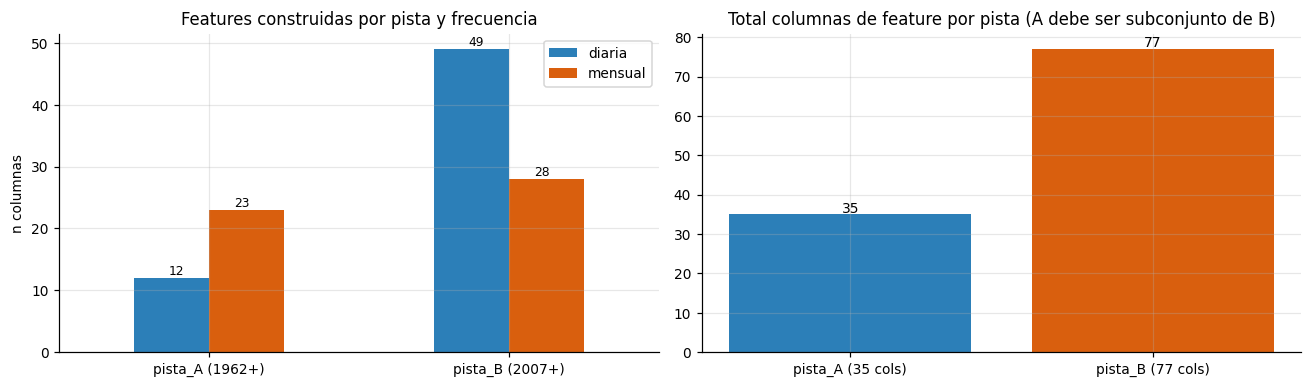

A subconjunto de B en columnas totales: True


In [31]:
# --- (a) Cobertura real por pista: cuantas de las filas de FEAT se construyeron ------------
fig, ax = plt.subplots(1, 2, figsize=(12, 3.6))
conteo = pd.DataFrame({
    'diaria':  [pistaA_diaria.shape[1], pistaB_diaria.shape[1]],
    'mensual': [len(base_cols_A_m), len(base_cols_B_m)],
}, index=['pista_A (1962+)', 'pista_B (2007+)'])
conteo.plot.bar(ax=ax[0], color=['#2c7fb8', '#d95f0e'], rot=0)
ax[0].set_title('Features construidas por pista y frecuencia'); ax[0].set_ylabel('n columnas')
for i, (idx, row) in enumerate(conteo.iterrows()):
    for j, v in enumerate(row.values):
        ax[0].text(i + (j - 0.5) * 0.22, v + 0.5, str(v), ha='center', fontsize=8)

tot = pd.Series({'pista_A (35 cols)': pistaA_diaria.shape[1] + len(base_cols_A_m),
                 'pista_B (77 cols)': pistaB_diaria.shape[1] + len(base_cols_B_m)})
ax[1].bar(tot.index, tot.values, color=['#2c7fb8', '#d95f0e'])
ax[1].set_title('Total columnas de feature por pista (A debe ser subconjunto de B)')
for i, v in enumerate(tot.values):
    ax[1].text(i, v + 0.5, str(v), ha='center', fontsize=9)
plt.tight_layout(); plt.show()
print('A subconjunto de B en columnas totales:', tot.iloc[0] <= tot.iloc[1])

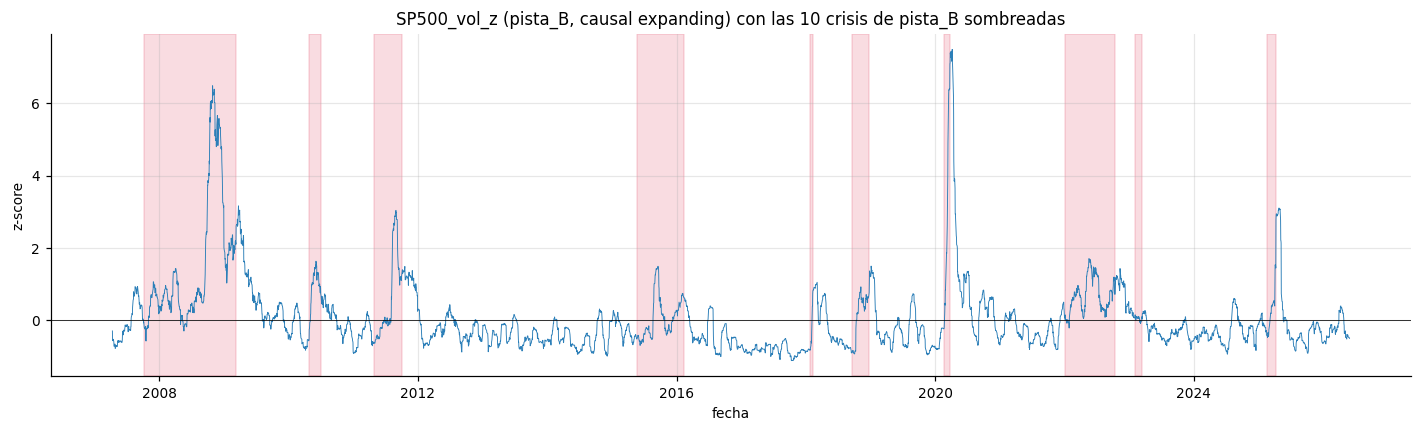

SP500_vol_z medio DENTRO de las 10 crisis de B: 0.856  vs FUERA: -0.144


In [32]:
# --- (b) Una feature nucleo (SP500_vol_z, pista_B) atravesando las 10 crisis congeladas -----
fig, ax = plt.subplots(figsize=(13, 4))
serie = pistaB_diaria['SP500_vol_z']
ax.plot(serie.index, serie.values, lw=.6, color='#2c7fb8')
ax.axhline(0, color='k', lw=.5)
crisis_b = crisis_windows_df[crisis_windows_df.pista == 'B']
for _, r in crisis_b.iterrows():
    ax.axvspan(r['inicio'], r['fin'], color='crimson', alpha=.15)
ax.set_title('SP500_vol_z (pista_B, causal expanding) con las 10 crisis de pista_B sombreadas')
ax.set_xlabel('fecha'); ax.set_ylabel('z-score')
plt.tight_layout(); plt.show()
print('SP500_vol_z medio DENTRO de las 10 crisis de B:',
      round(pd.concat([serie.loc[r['inicio']:r['fin']] for _, r in crisis_b.iterrows()]).mean(), 3),
      ' vs FUERA:', round(serie.drop(pd.concat([serie.loc[r['inicio']:r['fin']] for _, r in crisis_b.iterrows()]).index).mean(), 3))

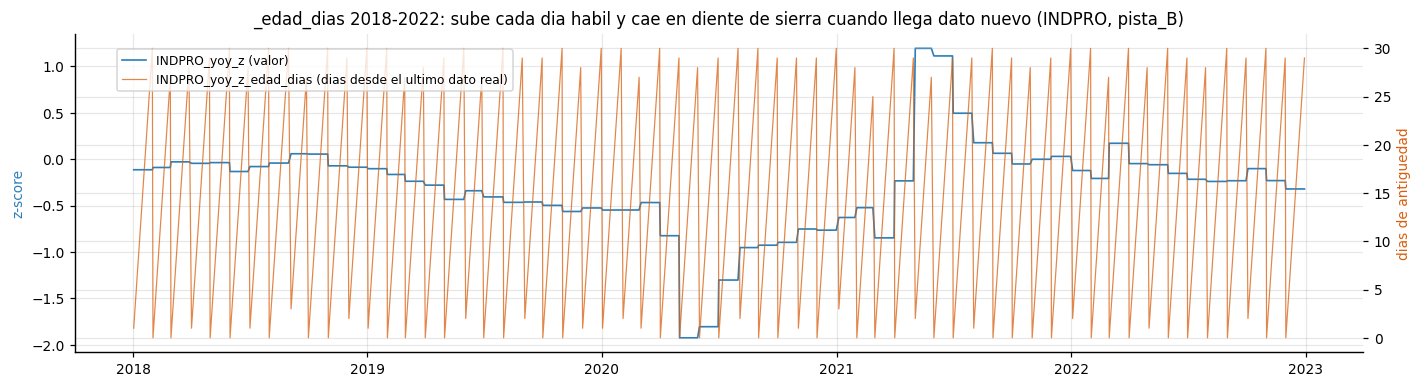

edad maxima observada en la ventana mostrada: 30 dias


In [33]:
# --- (c) _edad_dias: patron diente de sierra de una feature mensual con lag de publicacion --
fig, ax = plt.subplots(figsize=(13, 3.6))
ventana = pistaB_mensual.loc['2018':'2022']
ax2 = ax.twinx()
ax.plot(ventana.index, ventana['INDPRO_yoy_z'], color='#2c7fb8', lw=1.1, label='INDPRO_yoy_z (valor)')
ax2.plot(ventana.index, ventana['INDPRO_yoy_z_edad_dias'], color='#d95f0e', lw=.8, alpha=.75,
         label='INDPRO_yoy_z_edad_dias (dias desde el ultimo dato real)')
ax.set_ylabel('z-score', color='#2c7fb8'); ax2.set_ylabel('dias de antiguedad', color='#d95f0e')
ax.set_title('_edad_dias 2018-2022: sube cada dia habil y cae en diente de sierra cuando llega dato nuevo (INDPRO, pista_B)')
fig.legend(loc='upper left', bbox_to_anchor=(0.08, 0.88), fontsize=8)
plt.tight_layout(); plt.show()
print('edad maxima observada en la ventana mostrada:', int(ventana['INDPRO_yoy_z_edad_dias'].max()), 'dias')

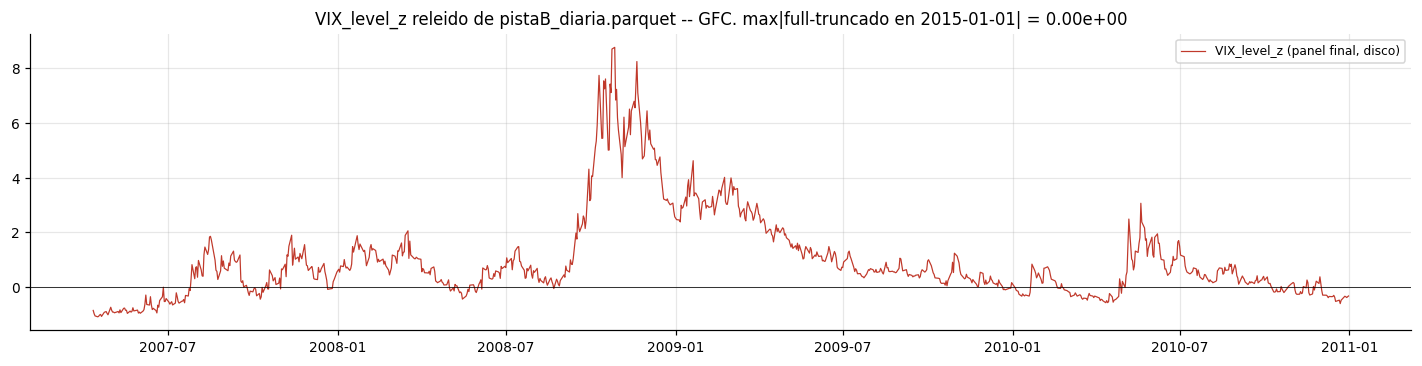

No-look-ahead confirmado sobre el fichero ESCRITO: max|Delta| = 0.00e+00 -> CAUSAL OK


In [34]:
# --- (d) Prueba visual de no-look-ahead sobre el panel YA ESCRITO A DISCO (no en memoria) ----
# Vuelve a leer pistaB_diaria.parquet del disco (no reusa la variable en memoria) para que la
# prueba cubra tambien la escritura/lectura de Seccion 8, no solo el calculo de Secciones 3-5.
releido = pd.read_parquet(ROOT / 'data' / 'processed' / 'pistaB_diaria.parquet')
cut = '2015-01-01'
vix_full = releido['VIX_level_z']
vix_hasta_cut_recalculado = ft.causal_zscore(_get(raw_B, 'VIX').loc[:cut])
idx = vix_hasta_cut_recalculado.index.intersection(vix_full.index)
idx = idx[idx <= pd.Timestamp(cut)]
diff = (vix_full.loc[idx] - vix_hasta_cut_recalculado.loc[idx]).abs()

fig, ax = plt.subplots(figsize=(13, 3.4))
ax.plot(vix_full.loc['2006':'2010'].index, vix_full.loc['2006':'2010'].values,
        lw=.8, color='#c0392b', label='VIX_level_z (panel final, disco)')
ax.axhline(0, c='k', lw=.5)
ax.set_title(f'VIX_level_z releido de pistaB_diaria.parquet -- GFC. max|full-truncado en {cut}| = {diff.max():.2e}')
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()
print(f'No-look-ahead confirmado sobre el fichero ESCRITO: max|Delta| = {diff.max():.2e} -> '
      + ('CAUSAL OK' if diff.max() < 1e-9 else 'LOOK-AHEAD!'))

## Cierre

`03_preprocesado.ipynb` implementó, sin rediseñar nada, el contrato congelado en `02_diseno_preprocesado.ipynb` §8-9 y `data/benchmark_spec.yaml`:

- **Resolución de nombres dirigida por catálogo** (§1): `load`/`tryload`/`load_subcolumn`, incluida la resolución explícita de `GW_PREDICTORS_MONTHLY -> 'b/m'` que ADR-002 §5 dejó pendiente a propósito para este notebook.
- **Carga cruda por pista** (§2): 41 series de `pista_A`, 106 de `pista_B`, exactamente las declaradas en `benchmark_spec.yaml`, con `A ⊆ B` verificado.
- **49 features diarias + 28 mensuales = 77 filas** (§3-4) de las 78 de la tabla `FEAT` de 02 (la fila 78 es `curve_tenors_apoyo`, `solo-raw`, no genera columna propia). Por pista se construyen menos, porque `benchmark_spec.yaml` no incluye todas las series fuente en las 41/106 congeladas: pista_A obtiene 12 diarias + 23 mensuales = 35 columnas, pista_B las 77 completas (49+28). Todas construidas con las primitivas causales de `src/features.py` (`causal_zscore`, `log_returns`, `realized_vol`, `drawdown`, `momentum`, `rolling_correlation`) o composiciones directas de ellas — nunca un método nuevo.
- **Alineación causal a rejilla NYSE** (§5): `reindex`+`ffill` para diarias, más columna `_edad_dias` por cada feature mensual arrastrada.
- **Ensamblado + aislamiento de labels** (§6): los 4 paneles de features y `labels` (crisis, falsos positivos, drawdown troughs) verificados como objetos disjuntos, sin columnas compartidas.
- **Gate de verificación en 4 frentes** (§7): causalidad del bloque núcleo (`max|Δ| < 1e-9`), cero fuga de series `rol=validation`, anidamiento `A ⊆ B`, y encaje de fechas dentro de la ventana congelada.
- **Escritura de salida** (§8, esta sección): `data/processed/pista{A,B}_{diaria,mensual}.parquet`, `labels.parquet` y `_meta.json` (ventana por pista, columnas `_edad_dias`, checksums SHA-256, resultados íntegros del gate de la Sección 7, y el hash del `benchmark_spec.yaml` de referencia).

**Siguiente paso: Fase D (detectores).** Consumen `pistaX_diaria.parquet`/`pistaX_mensual.parquet` como matriz de features `X` (ya causal, alineada, sin fuga) y `labels.parquet` + `_meta.json` **exclusivamente para evaluar** — nunca como entrada al detector. `03_preprocesado.ipynb` no toma más decisiones de diseño; cualquier cambio de alcance (nuevas series, otra columna de `GW_PREDICTORS_MONTHLY`, otra regla de frecuencia) debe volver primero a `02_diseno_preprocesado.ipynb` y a `benchmark_spec.yaml`.